# Introduction



<div style="text-align: center;">
    <img src="https://kajabi-storefronts-production.kajabi-cdn.com/kajabi-storefronts-production/themes/3332028/settings_images/V4Ra1KITLGxjVd7Xy0rw_file.jpg" alt="Centered Image">
</div>




# Weather Trend Forecasting
### PM Accelerator Tech Assessment

**PM Accelerator mission:** PM Accelerator supports aspiring and current product professionals — including AI/data practitioners — in building real, hands-on portfolio projects and developing the skills needed to break into and grow in tech careers, backed by mentorship and an active community.

---


**General Objective**

> Analyze global weather data from the `GlobalWeatherRepository.csv` dataset to identify trends, understand relationships between variables, and develop a model for forecasting weather conditions.

**Specific Objectives**

- Clean and prepare the data for analysis.
- Perform an exploratory data analysis (EDA) to identify trends and relationships between variables.
- Visualize the main characteristics of the data (temperature, precipitation, etc.).
- Build and evaluate one or more forecasting models using the `last_updated` variable.
- Compare the performance of the models and interpret the results.
- Conduct additional analyses such as anomaly detection, feature importance analysis, or spatial analysis.



## Install Package don't exist

In [ ]:
!pip install pandas
!pip install numpy
!pip install seaborn
!pip install matplotlib
!pip install scikit-learn
!pip install kagglehub

## Importing Libraries

In [ ]:
import os

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import kagglehub
import warnings
warnings.filterwarnings("ignore")
sns.set_style("darkgrid", {"grid.color": ".6",
                           "grid.linestyle": ":"})

from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split, TimeSeriesSplit, GridSearchCV
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error


from sklearn.feature_selection import VarianceThreshold, SelectKBest, mutual_info_regression, RFE


from scipy.stats import median_abs_deviation

plt.style.use('ggplot')
pd.set_option('display.max_columns', 50)



## Loading the Dataset

In [ ]:
# using kagglehub to download dataset
path = kagglehub.dataset_download("nelgiriyewithana/global-weather-repository")
print(path)

os.listdir(path)

df = pd.read_csv(f"{path}/GlobalWeatherRepository.csv")

100%|██████████| 12.2M/12.2M [00:00<00:00, 71.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/nelgiriyewithana/global-weather-repository/versions/1024


## Data Cleaning & Processing

In [ ]:
# information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 154946 entries, 0 to 154945
Data columns (total 41 columns):
 #   Column                        Non-Null Count   Dtype  
---  ------                        --------------   -----  
 0   country                       154946 non-null  object 
 1   location_name                 154946 non-null  object 
 2   latitude                      154946 non-null  float64
 3   longitude                     154946 non-null  float64
 4   timezone                      154946 non-null  object 
 5   last_updated_epoch            154946 non-null  int64  
 6   last_updated                  154946 non-null  object 
 7   temperature_celsius           154946 non-null  float64
 8   temperature_fahrenheit        154946 non-null  float64
 9   condition_text                154946 non-null  object 
 10  wind_mph                      154946 non-null  float64
 11  wind_kph                      154946 non-null  float64
 12  wind_degree                   154946 non-nul

In [ ]:
# change last_updated to datetime dtype
df["last_updated"] = pd.to_datetime(df["last_updated"])

print("Date range:", df['last_updated'].min(), "->", df['last_updated'].max())

Date range: 2024-05-16 01:45:00 -> 2026-07-23 18:45:00


In [ ]:
df.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,79.8,Partly Cloudy,8.3,13.3,338,NNW,1012.0,29.89,0.0,0.00,24,30,25.3,77.5,10.0,6.0,7.0,9.5,15.3,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,66.2,Partly cloudy,6.9,11.2,320,NW,1012.0,29.88,0.1,0.00,94,75,19.0,66.2,10.0,6.0,5.0,11.4,18.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,73.4,Sunny,9.4,15.1,280,W,1011.0,29.85,0.0,0.00,29,0,24.6,76.4,10.0,6.0,5.0,13.9,22.3,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,43.3,Light drizzle,7.4,11.9,215,SW,1007.0,29.75,0.3,0.01,61,100,3.8,38.9,2.0,1.0,2.0,8.5,13.7,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,78.8,Partly cloudy,8.1,13.0,150,SSE,1011.0,29.85,0.0,0.00,89,50,28.7,83.6,10.0,6.0,8.0,12.5,20.2,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [ ]:
# Missing Values/Null Values Count
df.isna().sum().sort_values(ascending=False)



,0
country,0
location_name,0
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0


In [ ]:
# duplicate check
dup_full = df.duplicated().sum()
# duplicate check with latitude, longitude and last_updated
dup_key = df.duplicated(subset=["latitude", "longitude", "last_updated"]).sum()
print("Fully duplicated rows:", dup_full)
print("Duplicated on (location_name, last_updated):", dup_key)


Fully duplicated rows: 0
Duplicated on (location_name, last_updated): 1


In [ ]:
# Show duplicate row in df
df[df.duplicated(subset=["latitude", "longitude", "last_updated"], keep=False)]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,temperature_fahrenheit,condition_text,wind_mph,wind_kph,wind_degree,wind_direction,pressure_mb,pressure_in,precip_mm,precip_in,humidity,cloud,feels_like_celsius,feels_like_fahrenheit,visibility_km,visibility_miles,uv_index,gust_mph,gust_kph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
125208,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00:00,32.2,90.0,Partly Cloudy,2.7,4.3,178,S,1015.0,29.97,0.0,0.0,43,25,31.5,88.6,10.0,6.0,6.7,3.1,5.0,510.85,26.0,14.75,2.95,21.55,21.55,2,2,06:42 AM,06:19 PM,08:21 AM,08:58 PM,Waxing Crescent,6
125244,Thailand,Nan,18.7833,100.7833,Asia/Bangkok,1771570800,2026-02-20 14:00:00,32.2,90.0,Partly Cloudy,2.7,4.3,178,S,1015.0,29.97,0.0,0.0,43,25,31.5,88.6,10.0,6.0,6.7,3.1,5.0,510.85,26.0,14.75,2.95,21.55,21.55,2,2,06:30 AM,06:54 PM,09:05 AM,09:14 PM,Waxing Crescent,8


In [ ]:
# drop first duplicate occurence
df = df.drop_duplicates(subset=["latitude", "longitude", "last_updated"], keep="last")

## Recheck NaN and Null values

In [ ]:
df = df.apply(lambda x: x.str.strip() if x.dtype == "object" else x)
df.isin(["Nan", "NaN", "nan", "NAN", "null", "NULL", "Null"]).sum()

,0
country,0
location_name,795
latitude,0
longitude,0
timezone,0
last_updated_epoch,0
last_updated,0
temperature_celsius,0
temperature_fahrenheit,0
condition_text,0




```
After analysis, we found 783 "Nan" values in the `location_name` column.
 Using the latitude and longitude columns, we could determine these values using reverse geocoding.
 However, after searching online using latitude and longitude,
 I realized that it's actually the city name that's "Nan" and not a mistake.
```



In [ ]:
# Count by unique Country
print(f"We have {df["country"].nunique()} countries in the dataset.")

We have 211 countries in the dataset.


In [ ]:
# Counts the number of times a country appears in the dataset.
pd.set_option('display.max_rows', None)
print(f"List of country occurrence counts \n {df['country'].value_counts()}")
pd.reset_option('display.max_rows')

List of country occurrence counts 
 country
Bulgaria                            1826
Indonesia                           1594
Thailand                            1590
Turkey                              1587
Sudan                               1587
Bolivia                             1580
Iran                                1547
Belgium                             1496
Madagascar                          1254
Vietnam                             1250
Hungary                              914
Russia                               850
Switzerland                          846
Senegal                              846
Norway                               808
Kenya                                798
Burundi                              797
Ghana                                797
Chad                                 797
Vatican City                         797
Japan                                797
Malta                                797
Ukraine                              797
Yemen        

##  Standardize mixed-language country names

In [ ]:
# Based on the result from the previous cell, we observe that the dataset
# mixes country names in English, Portuguese, Russian, Arabic, German, and Chinese (e.g., "Malásia", "Польша", "火鸡").

country_name_fix = {
    'Democratic Republic of Congo': 'DR Congo',
    'Fiji Islands': 'Fiji',
    'Kyrghyzstan': 'Kyrgyzstan',
    'Cote d\'Ivoire': 'Ivory Coast',
    'Seychelles Islands': 'Seychelles',
    'USA United States of America': 'United States',
    'United States of America': 'United States',
    'Malásia': 'Malaysia',
    'Komoren': 'Comoros',
    'كولومبيا': 'Colombia',
    'Estonie': 'Estonia',
    'Гватемала': 'Guatemala',
    'Inde': 'India',
    'Letonia': 'Latvia',
    'Польша': 'Poland',
    'Mexique': 'Mexico',
    'Polônia': 'Poland',
    'Marrocos': 'Morocco',
    'Турция': 'Turkey',
    'Saudi Arabien': 'Saudi Arabia',
    'Südkorea': 'South Korea',
    'Bélgica': 'Belgium',
    'Turkménistan': 'Turkmenistan',
    '火鸡': 'Turkey',
    'Jemen': 'Yemen',
}

n_renamed = df['country'].isin(country_name_fix.keys()).sum()
n_before_country_standardize = df['country'].nunique()
df['country'] = df['country'].replace(country_name_fix)

print(f"Rows with non-English country name standardized: {n_renamed}")
print(f"Unique countries: before= {n_before_country_standardize}  after= {df['country'].nunique()}")


Rows with non-English country name standardized: 4324
Unique countries: before= 211  after= 192


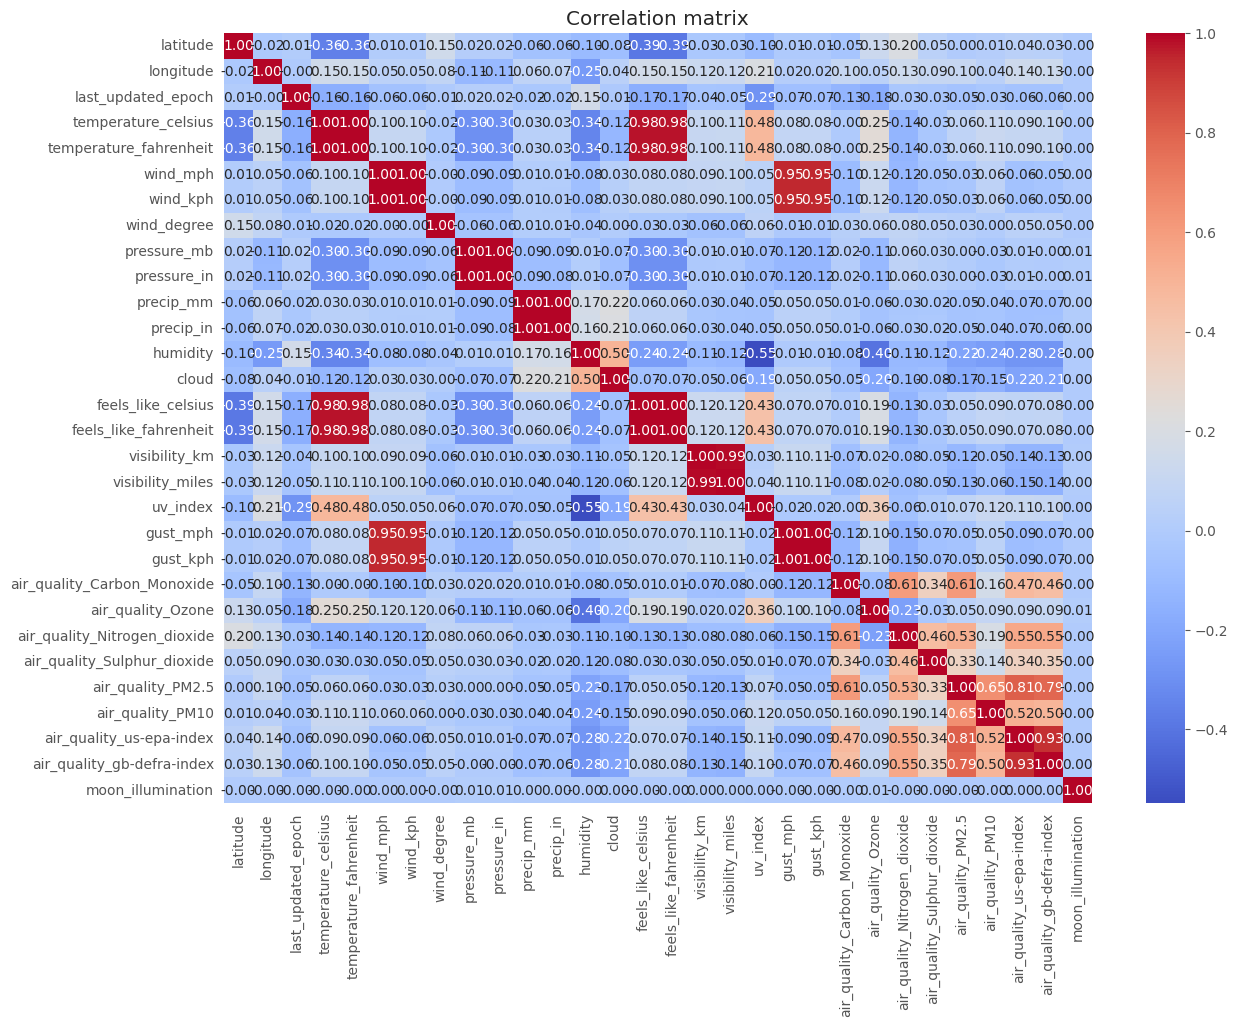

In [ ]:
# Correlation matrix
plt.figure(figsize=(14, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation matrix")
plt.show()

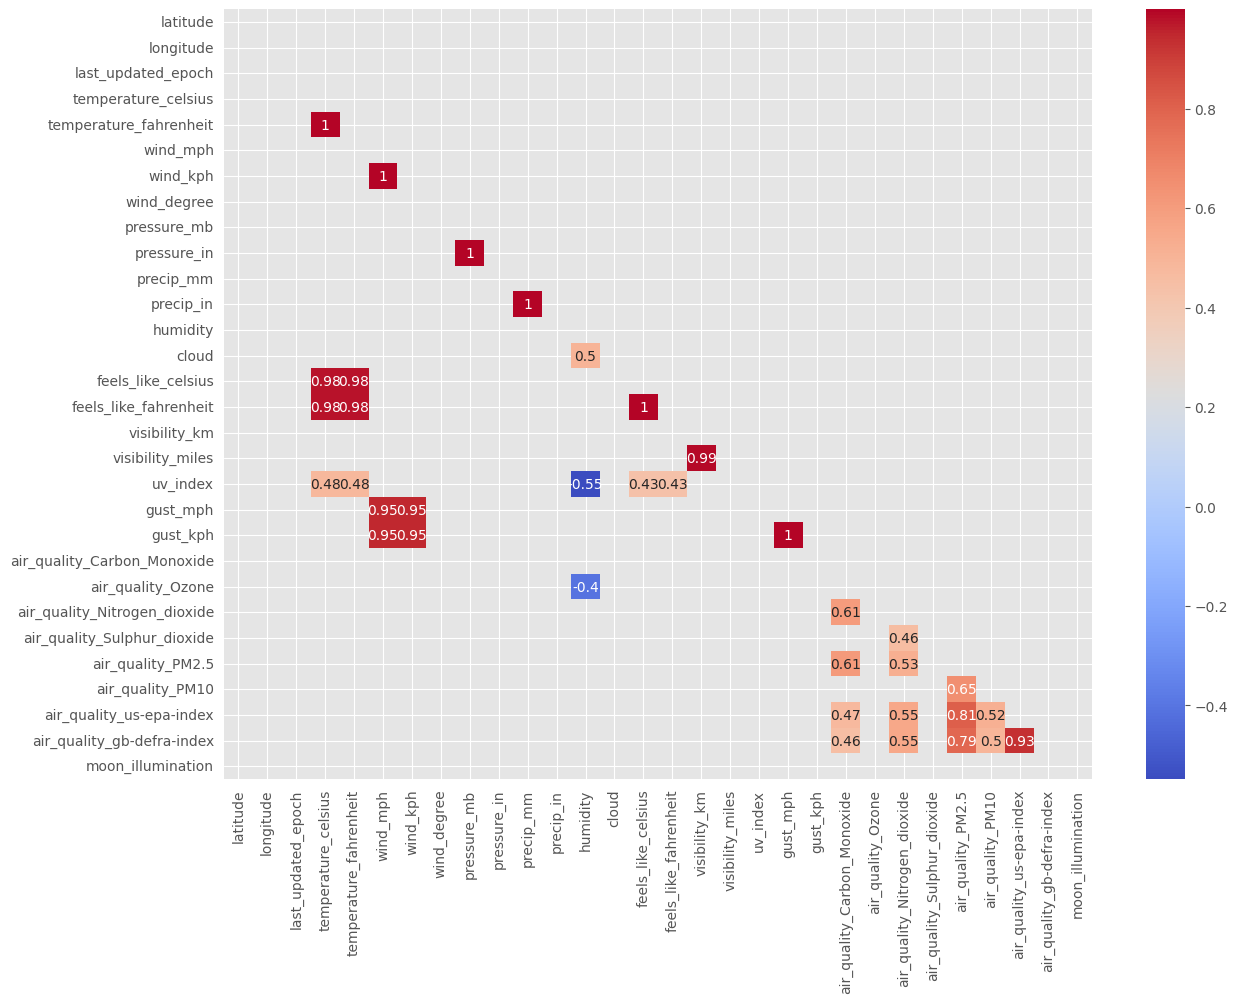

In [ ]:
# The heatmap filtered at ≥ 0.4 allows for the visualization of significant correlations.
# Among these, pairs with a correlation ≥ 0.99 are considered redundant and will be removed.

corr = df.corr(numeric_only=True)
mask = np.triu(np.ones_like(corr, dtype=bool))
plt.figure(figsize=(14, 10))
corr_filtered = corr.where(np.abs(corr) >= 0.4)
sns.heatmap(corr_filtered, mask=mask, annot=True, cmap='coolwarm')
plt.show()



```
Based on the correlation matrix, we decide to remove columns deemed to be
duplicates due to a high Pearson correlation coefficient ( corr >= 0.99).
```



In [ ]:
#Based on the heatmap, these columns are redundant (corr >= 0.99)
cols_to_drop = [
    'temperature_fahrenheit',  # corr = 1.0 with temperature_celsius
    'wind_kph',                # corr = 1.0 with wind_mph
    'pressure_in',             # corr = 1.0 with pressure_mb
    'precip_in',               # corr = 1.0 with precip_mm
    'visibility_miles',        # corr = 1.0 with visibility_km
    'gust_kph',                # corr = 1.0 with gust_mph
    'feels_like_fahrenheit',   # corr = 1.0 with feels_like_celsius
]

df_after_redundant_columns = df.drop(columns=cols_to_drop)
print(f"Remaining columns: {df_after_redundant_columns.shape[1]}")

Remaining columns: 34


In [ ]:
df_after_redundant_columns.shape[1]

34

In [ ]:
df_after_redundant_columns.head()

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_mph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_mph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination
0,Afghanistan,Kabul,34.52,69.18,Asia/Kabul,1715849100,2024-05-16 13:15:00,26.6,Partly Cloudy,8.3,338,NNW,1012.0,0.0,24,30,25.3,10.0,7.0,9.5,277.0,103.0,1.1,0.2,8.4,26.6,1,1,04:50 AM,06:50 PM,12:12 PM,01:11 AM,Waxing Gibbous,55
1,Albania,Tirana,41.33,19.82,Europe/Tirane,1715849100,2024-05-16 10:45:00,19.0,Partly cloudy,6.9,320,NW,1012.0,0.1,94,75,19.0,10.0,5.0,11.4,193.6,97.3,0.9,0.1,1.1,2.0,1,1,05:21 AM,07:54 PM,12:58 PM,02:14 AM,Waxing Gibbous,55
2,Algeria,Algiers,36.76,3.05,Africa/Algiers,1715849100,2024-05-16 09:45:00,23.0,Sunny,9.4,280,W,1011.0,0.0,29,0,24.6,10.0,5.0,13.9,540.7,12.2,65.1,13.4,10.4,18.4,1,1,05:40 AM,07:50 PM,01:15 PM,02:14 AM,Waxing Gibbous,55
3,Andorra,Andorra La Vella,42.50,1.52,Europe/Andorra,1715849100,2024-05-16 10:45:00,6.3,Light drizzle,7.4,215,SW,1007.0,0.3,61,100,3.8,2.0,2.0,8.5,170.2,64.4,1.6,0.2,0.7,0.9,1,1,06:31 AM,09:11 PM,02:12 PM,03:31 AM,Waxing Gibbous,55
4,Angola,Luanda,-8.84,13.23,Africa/Luanda,1715849100,2024-05-16 09:45:00,26.0,Partly cloudy,8.1,150,SSE,1011.0,0.0,89,50,28.7,10.0,8.0,12.5,2964.0,19.0,72.7,31.5,183.4,262.3,5,10,06:12 AM,05:55 PM,01:17 PM,12:38 AM,Waxing Gibbous,55


In [ ]:
# Summarize key statistics (mean, standard deviation, min, max, quartiles, etc.)
# for each numerical column, with a more readable layout

df_after_redundant_columns.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,154945.0,19.247136,-41.3,4.0503,17.25,40.4,65.3,24.395719
longitude,154945.0,21.873152,-175.2,-6.8361,21.4333,49.8822,179.22,65.776111
last_updated_epoch,154945.0,1750334464.613895,1715849100.0,1733136300.0,1750323600.0,1767510000.0,1784785500.0,19908503.500003
last_updated,154945,2025-06-19 14:10:44.425441536,2024-05-16 01:45:00,2024-12-02 12:45:00,2025-06-19 12:00:00,2026-01-04 07:45:00,2026-07-23 18:45:00,NaN
temperature_celsius,154945.0,21.379581,-29.8,16.1,23.7,27.9,79.3,9.468887
wind_mph,154945.0,7.930821,2.2,3.8,6.7,10.7,1841.2,6.979247
wind_degree,154945.0,169.683042,1.0,81.0,163.0,257.0,360.0,103.528961
pressure_mb,154945.0,1014.050379,947.0,1010.0,1014.0,1018.0,3006.0,9.92487
precip_mm,154945.0,0.131559,0.0,0.0,0.0,0.02,42.24,0.556653
humidity,154945.0,66.995502,2.0,52.0,72.0,86.0,100.0,23.615957


## Outlier handling & imputation — one reusable function

The first draft of this notebook wrote the same "cap out-of-range values to NaN, then
either drop or group-median-impute depending on how much data that would cost us" logic
three separate times (negative air-quality readings, physical wind/pressure limits, and
the IQR-based air-quality cap) — plus a fourth patch cell later to mop up NaNs the first
two passes left behind. That's refactored into a single function here, called three times
below. Capping and imputing happen in the same call now, so there's no leftover-NaN cell
needed afterward.

In [ ]:
def cap_and_impute(df, col, lower=None, upper=None, group_col='country', pct_threshold=5.0):
    """
    Replace values outside [lower, upper] with NaN, then either drop those rows
    (if they're a small fraction of the data) or fill them with the group-median
    (if dropping would cost us too much data). Prints a short diagnostic either way.
    """
    total = len(df)
    mask_bad = pd.Series(False, index=df.index)
    if lower is not None:
        mask_bad |= (df[col] < lower)
    if upper is not None:
        mask_bad |= (df[col] > upper)

    n_bad = mask_bad.sum()
    if n_bad == 0:
        return df

    pct = n_bad / total * 100
    bound_desc = f"outside [{lower}, {upper}]"
    print(f"{col}: {n_bad} values {bound_desc} ({pct:.2f}%)")

    df = df.copy()
    df.loc[mask_bad, col] = np.nan

    if pct < pct_threshold:
        df = df.dropna(subset=[col])
        print(f"     -> under {pct_threshold}% : rows dropped")
    else:
        median_val = df.groupby(group_col)[col].transform('median')
        df[col] = df[col].fillna(median_val)
        print(f"     -> {pct_threshold}%+ : filled with {group_col}-level median")

    return df


In [ ]:
# Negative air-quality readings are physically impossible - almost certainly faulty
# sensors. We cap them to NaN and then drop/impute using the shared helper.
air_quality_cols = [
    'air_quality_Carbon_Monoxide',
    'air_quality_Ozone',
    'air_quality_Nitrogen_dioxide',
    'air_quality_Sulphur_dioxide',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

for col in air_quality_cols:
    df_after_redundant_columns = cap_and_impute(df_after_redundant_columns, col, lower=0)


air_quality_Carbon_Monoxide: 1 values outside [0, None] (0.00%)
     -> under 5.0% : rows dropped
air_quality_Sulphur_dioxide: 1 values outside [0, None] (0.00%)
     -> under 5.0% : rows dropped
air_quality_PM10: 2 values outside [0, None] (0.00%)
     -> under 5.0% : rows dropped


In [ ]:
# Realistic physical limits (Guinness World Records):
# wind_mph / gust_mph: fastest recorded wind speed = 253 mph
# pressure_mb: highest recorded barometric pressure = 1083 mb
physical_limits = {
    'wind_mph': 253,
    'gust_mph': 253,
    'pressure_mb': 1083,
}

for col, limit in physical_limits.items():
    df_after_redundant_columns = cap_and_impute(df_after_redundant_columns, col, upper=limit)


wind_mph: 1 values outside [None, 253] (0.00%)
     -> under 5.0% : rows dropped
pressure_mb: 2 values outside [None, 1083] (0.00%)
     -> under 5.0% : rows dropped


In [ ]:
df_after_redundant_columns.describe().T

,count,mean,min,25%,50%,75%,max,std
latitude,154938.0,19.247283,-41.3,4.0503,17.25,40.4,65.3,24.396101
longitude,154938.0,21.872884,-175.2,-6.8361,21.4333,49.8822,179.22,65.775493
last_updated_epoch,154938.0,1750335155.094296,1715849100.0,1733136300.0,1750323600.0,1767510000.0,1784785500.0,19908370.002339
last_updated,154938,2025-06-19 14:22:14.943655168,2024-05-16 01:45:00,2024-12-02 12:48:45,2025-06-19 12:00:00,2026-01-04 07:56:15,2026-07-23 18:45:00,NaN
temperature_celsius,154938.0,21.379722,-29.8,16.1,23.7,27.9,79.3,9.46887
wind_mph,154938.0,7.918827,2.2,3.8,6.7,10.7,169.1,5.197856
wind_degree,154938.0,169.6843,1.0,81.0,163.0,257.0,360.0,103.528508
pressure_mb,154938.0,1014.02461,947.0,1010.0,1014.0,1018.0,1080.0,6.887692
precip_mm,154938.0,0.131562,0.0,0.0,0.0,0.02,42.24,0.556665
humidity,154938.0,66.995792,2.0,52.0,72.0,86.0,100.0,23.616082


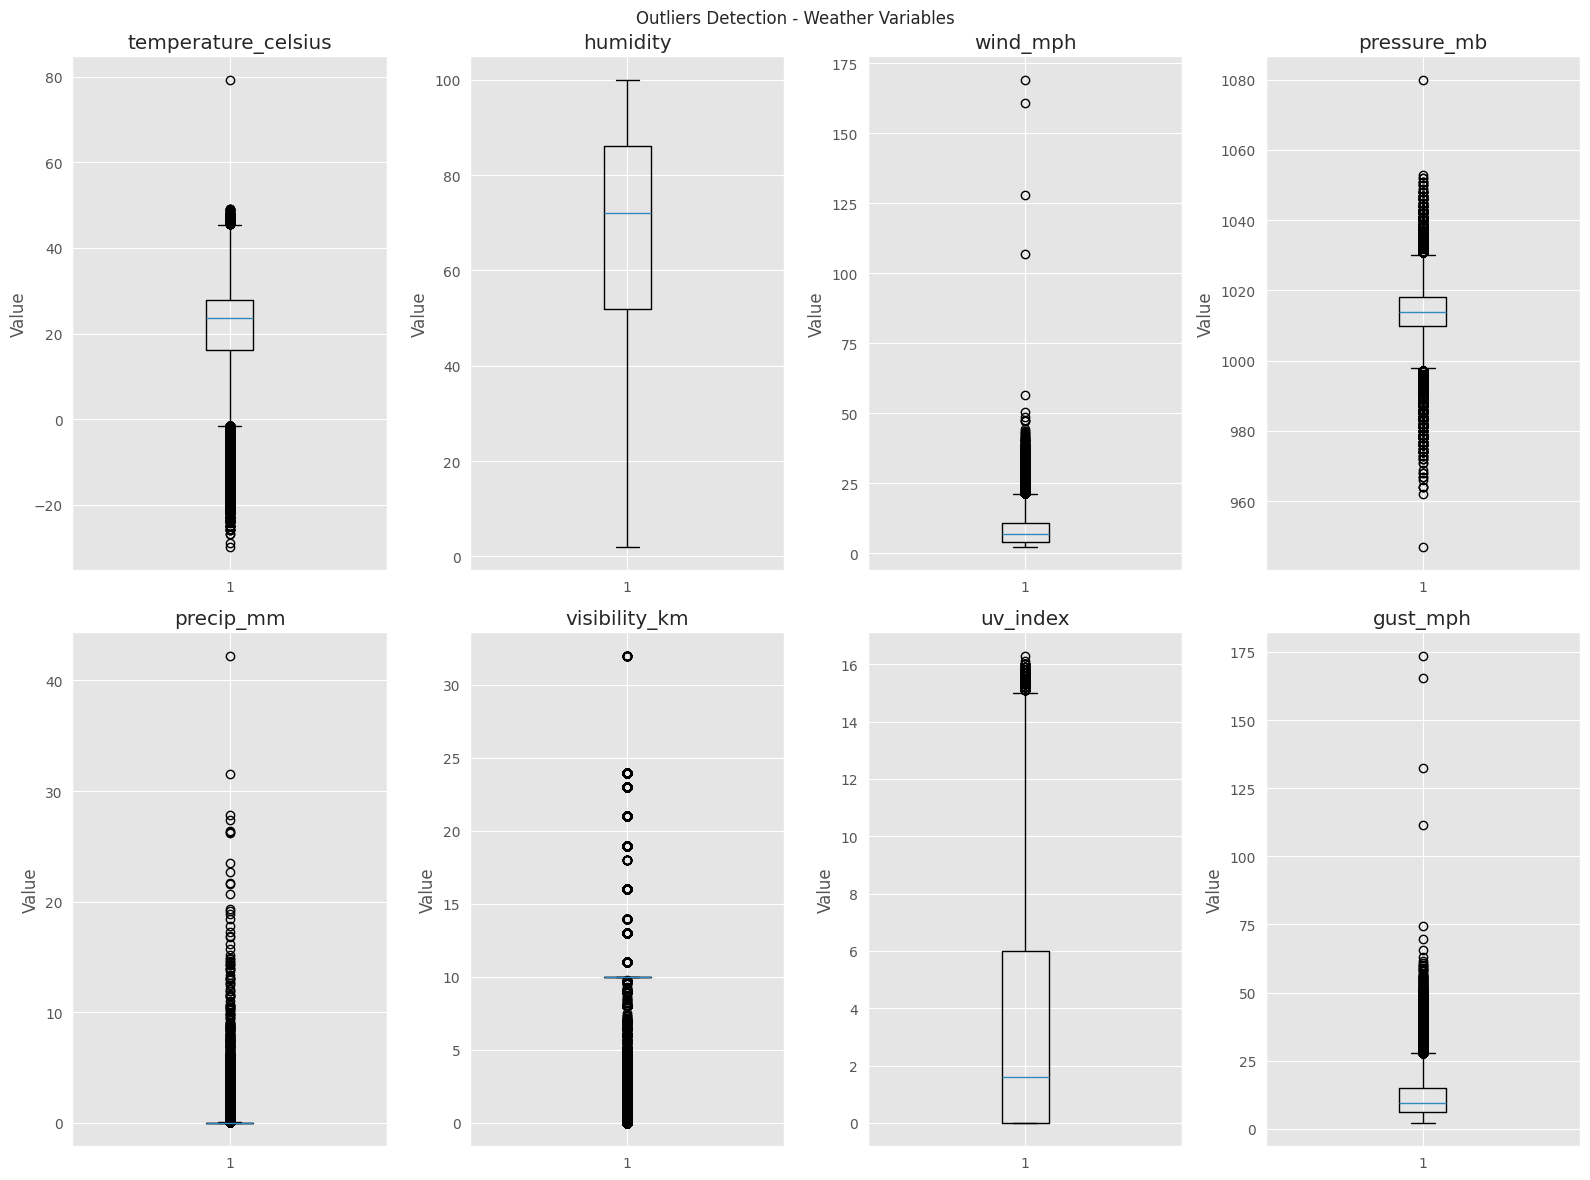

In [ ]:
# Key weather columns to inspect
meteo_cols = [
    'temperature_celsius', 'humidity', 'wind_mph',
    'pressure_mb', 'precip_mm', 'visibility_km',
    'uv_index', 'gust_mph'
]

fig, axes = plt.subplots(2, 4, figsize=(16, 12))
axes = axes.flatten()

for i, col in enumerate(meteo_cols):
    axes[i].boxplot(df_after_redundant_columns[col].dropna())
    axes[i].set_title(col)
    axes[i].set_ylabel('Value')

plt.suptitle('Outliers Detection - Weather Variables')
plt.tight_layout()
plt.show()

## Positive outliers - air quality

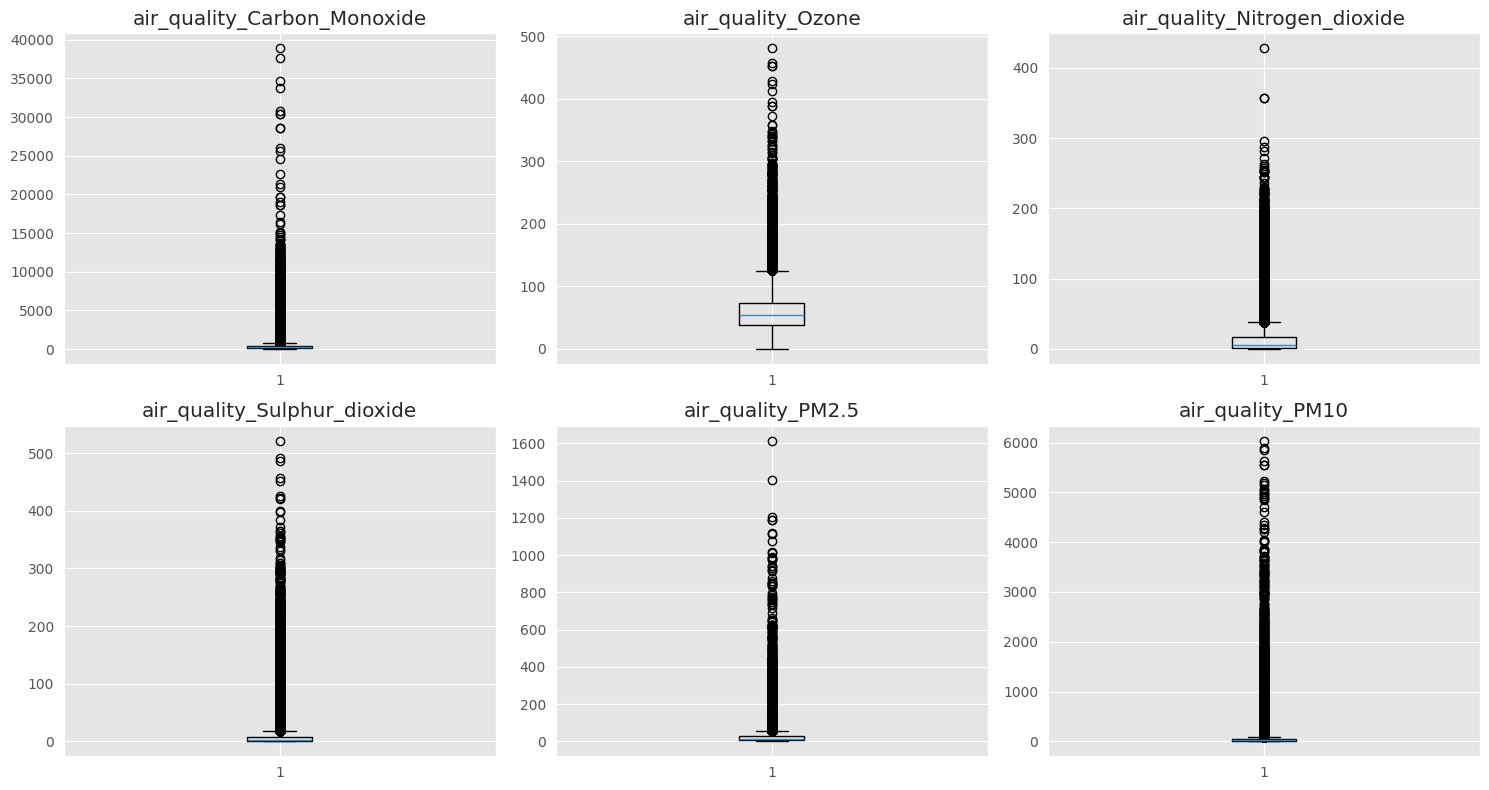

In [ ]:
# check the scale before deciding anything
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(air_quality_cols):
    axes[i].boxplot(df_after_redundant_columns[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
# No official max for pollution sensors (unlike wind/pressure), so IQR-based capping
# instead. Using 3x IQR (not the usual 1.5x) so we don't cut real extreme-pollution
# events, just sensor glitches.
for col in air_quality_cols:
    q1 = df_after_redundant_columns[col].quantile(0.25)
    q3 = df_after_redundant_columns[col].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 3 * iqr
    df_after_redundant_columns = cap_and_impute(df_after_redundant_columns, col, upper=upper_bound)


air_quality_Carbon_Monoxide: 7206 values outside [None, 1194.8500000000001] (4.65%)
     -> under 5.0% : rows dropped
air_quality_Ozone: 650 values outside [None, 175.0] (0.44%)
     -> under 5.0% : rows dropped
air_quality_Nitrogen_dioxide: 6350 values outside [None, 51.245000000000005] (4.32%)
     -> under 5.0% : rows dropped
air_quality_Sulphur_dioxide: 10094 values outside [None, 19.2] (7.17%)
     -> 5.0%+ : filled with country-level median
air_quality_PM2.5: 3942 values outside [None, 70.6] (2.80%)
     -> under 5.0% : rows dropped
air_quality_PM10: 6213 values outside [None, 97.91999999999999] (4.54%)
     -> under 5.0% : rows dropped


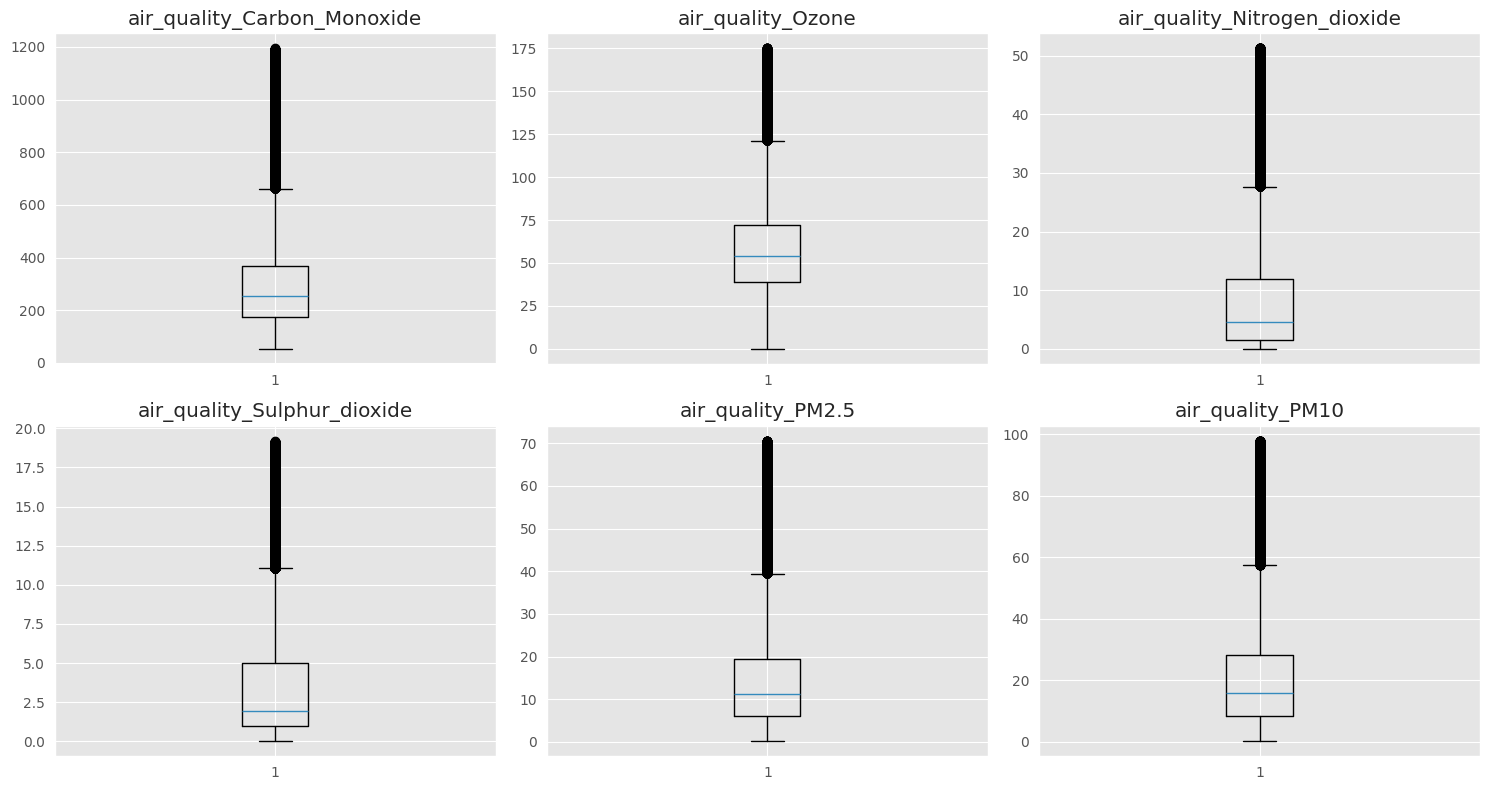

In [ ]:
# recheck after treatment
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(air_quality_cols):
    axes[i].boxplot(df_after_redundant_columns[col].dropna())
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

## Recheck missing values one more time

In [ ]:
remaining_na = df_after_redundant_columns.isna().sum()
remaining_na = remaining_na[remaining_na > 0].sort_values(ascending=False)
remaining_na

,0


## EDA - Temperature

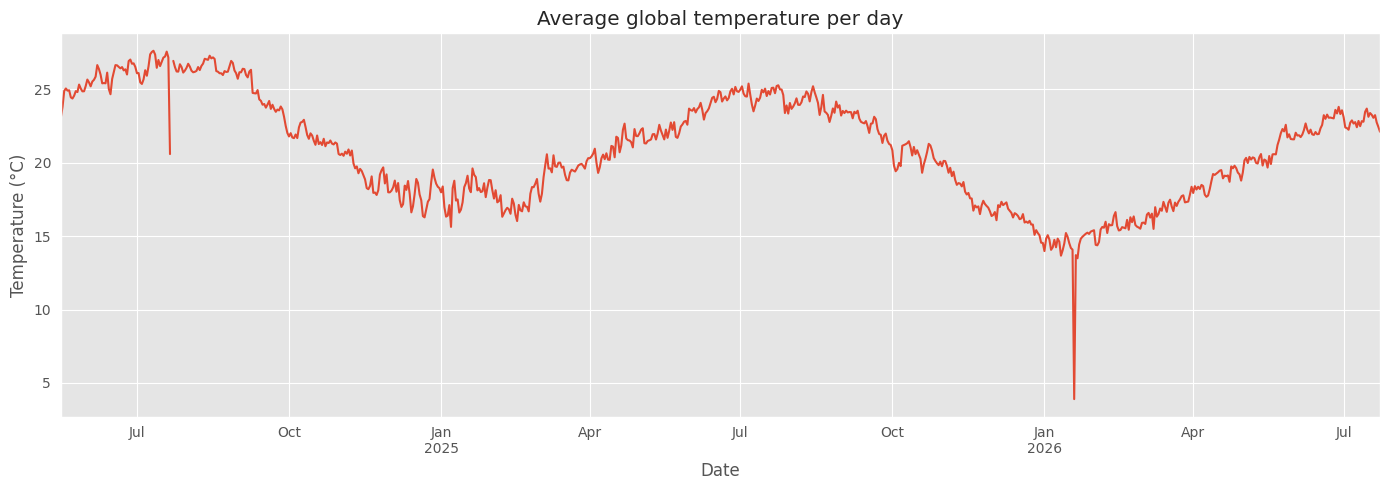

In [ ]:
daily_temp = (
    df_after_redundant_columns
    .set_index('last_updated')['temperature_celsius']
    .resample('D')
    .mean()
)

plt.figure(figsize=(14, 5))
daily_temp.plot()
plt.title('Average global temperature per day')
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.tight_layout()
plt.show()

## EDA - Precipitation

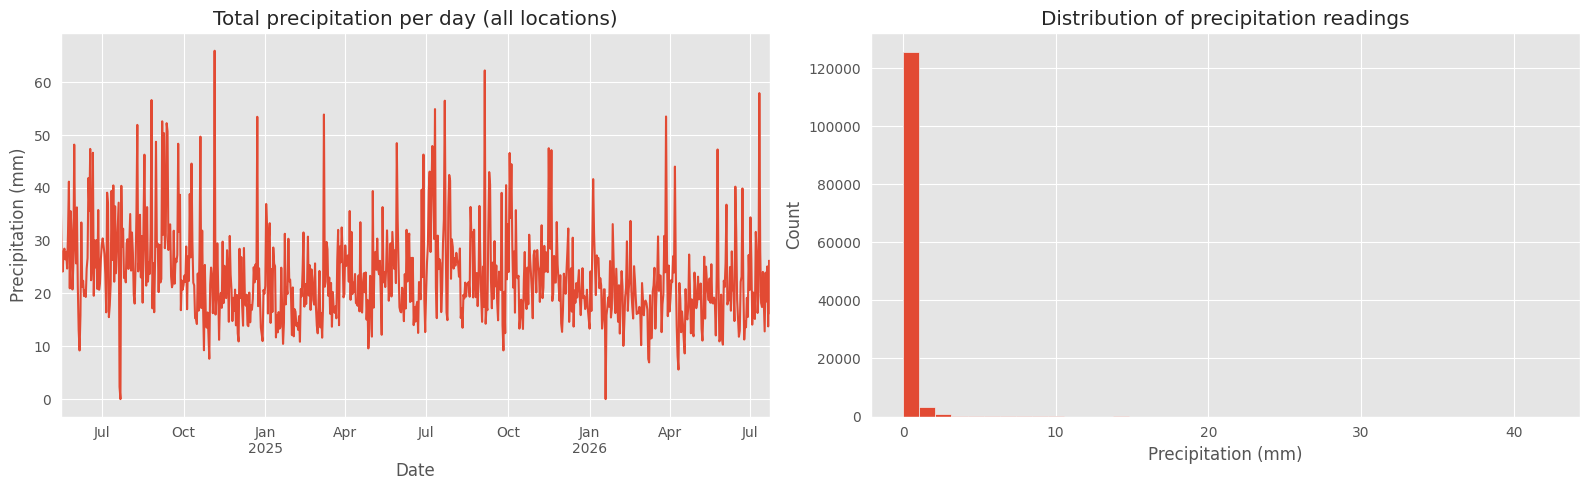

In [ ]:
# precip is spikier than temp (most days dry), line plot alone not very readable so adding a histogram too
daily_precip = (
    df_after_redundant_columns
    .set_index('last_updated')['precip_mm']
    .resample('D')
    .sum()
)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

daily_precip.plot(ax=axes[0])
axes[0].set_title('Total precipitation per day (all locations)')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Precipitation (mm)')

axes[1].hist(df_after_redundant_columns['precip_mm'].dropna(), bins=40)
axes[1].set_title('Distribution of precipitation readings')
axes[1].set_xlabel('Precipitation (mm)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

# Anomaly Detection

We don't have labeled anomalies for global weather, so the goal here is different: flag unusual days in the daily global average temperature series using three unsupervised methods and compare where they agree, rather than score against a known answer.

1. Robust z-score / MAD (median absolute deviation).
2. Isolation Forest
3. Local Outlier Factor (novelty mode) — density-based, catches a different kind of anomaly than Isolation Forest, so agreement between the two is a useful sanity check.


In [ ]:
anomaly_df = daily_temp.to_frame('temperature_celsius').dropna()

median_temp = np.median(anomaly_df['temperature_celsius'])
mad_temp = median_abs_deviation(anomaly_df['temperature_celsius'])

anomaly_df['robust_z'] = 0.6745 * (anomaly_df['temperature_celsius'] - median_temp) / mad_temp
anomaly_df['mad_flag'] = np.where(anomaly_df['robust_z'].abs() >= 3.5, -1, 1)

print(f"MAD baseline flagged {(anomaly_df['mad_flag'] == -1).sum()} anomalous day(s)")


MAD baseline flagged 1 anomalous day(s)


In [ ]:
# --- 2. Isolation Forest ---
iso_forest = IsolationForest(contamination=0.02, random_state=42)
X_anom = anomaly_df[['temperature_celsius']].values
anomaly_df['iso_flag'] = iso_forest.fit_predict(X_anom)

print(f"Isolation Forest flagged {(anomaly_df['iso_flag'] == -1).sum()} anomalous day(s)")

# --- 3. Local Outlier Factor (novelty=True so we can .predict on the same data) ---
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.02, novelty=True)
lof.fit(X_anom)
anomaly_df['lof_flag'] = lof.predict(X_anom)

print(f"Local Outlier Factor flagged {(anomaly_df['lof_flag'] == -1).sum()} anomalous day(s)")

agreement = ((anomaly_df['iso_flag'] == -1) & (anomaly_df['lof_flag'] == -1)).sum()
print(f"Days flagged by BOTH Isolation Forest and LOF: {agreement}")


Isolation Forest flagged 16 anomalous day(s)
Local Outlier Factor flagged 13 anomalous day(s)
Days flagged by BOTH Isolation Forest and LOF: 7


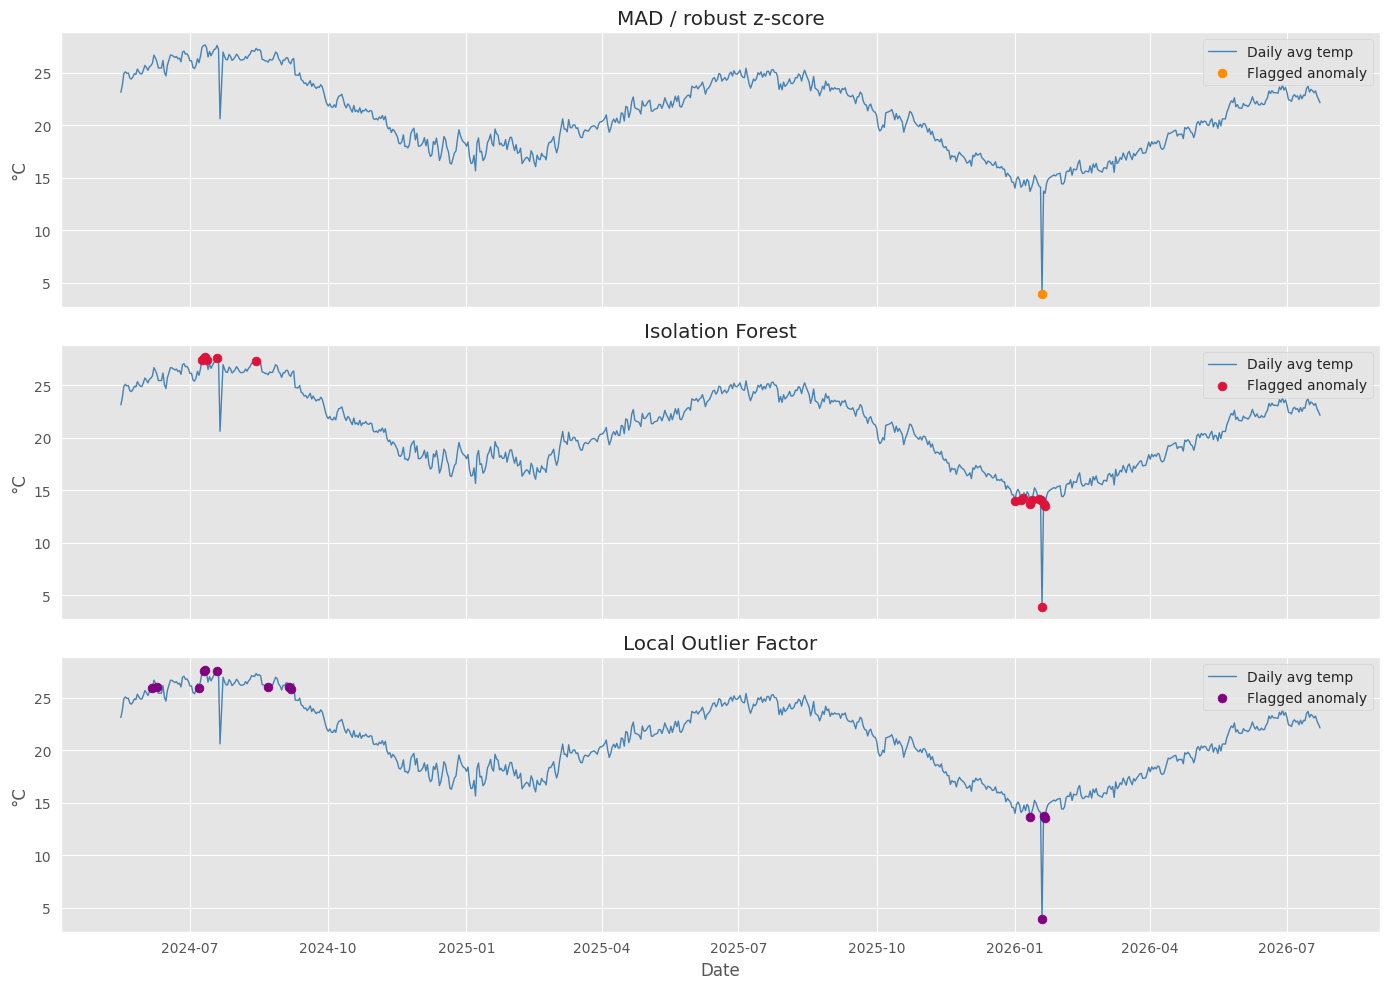

In [ ]:
# Visual comparison: overlay each method's flagged days on the temperature series
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

methods = [('mad_flag', 'MAD / robust z-score', 'darkorange'),
           ('iso_flag', 'Isolation Forest', 'crimson'),
           ('lof_flag', 'Local Outlier Factor', 'purple')]

for ax, (flag_col, title, color) in zip(axes, methods):
    ax.plot(anomaly_df.index, anomaly_df['temperature_celsius'], color='steelblue', linewidth=1, label='Daily avg temp')
    flagged = anomaly_df[anomaly_df[flag_col] == -1]
    ax.scatter(flagged.index, flagged['temperature_celsius'], color=color, s=40, zorder=5, label='Flagged anomaly')
    ax.set_title(title)
    ax.set_ylabel('°C')
    ax.legend(loc='upper right')

plt.xlabel('Date')
plt.tight_layout()
plt.show()


# Advanced EDA - Climate & Geography

## Country to continent

In [ ]:
#df_after_redundant_columns["continent"] = df_after_redundant_columns["timezone"].str.split("/").str[0]

In [ ]:
#df_after_redundant_columns.head(10)

In [ ]:
!pip install pycountry-convert -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 256.2/256.2 kB 13.3 MB/s eta 0:00:00


In [ ]:
import pycountry_convert as pc

def country_to_continent(country_name):
    try:
        alpha2 = pc.country_name_to_country_alpha2(country_name)
        continent_code = pc.country_alpha2_to_continent_code(alpha2)
        return pc.convert_continent_code_to_continent_name(continent_code)
    except Exception:
        return None

unique_countries = df_after_redundant_columns['country'].unique()
country_continent_map = {c: country_to_continent(c) for c in unique_countries}

unmapped = [c for c, cont in country_continent_map.items() if cont is None]
print(f"{len(unmapped)} countries not recognized :")
print(unmapped)

5 countries not recognized :
['DR Congo', 'Vatican City', 'Timor-Leste', 'Kosovo', 'Saint-Vincent-et-les-Grenadines']


In [ ]:
# patching what pycountry_convert missed, not exhaustive - check the print above if you rerun on updated data
manual_continent_fix = {
    'DR Congo': 'Africa',
    'Vatican City': 'Europe',
    'Timor-Leste': 'Asia',
    'Kosovo': 'Europe',
    'Saint-Vincent-et-les-Grenadines': 'North America'
}
country_continent_map.update(manual_continent_fix)

df_after_redundant_columns['continent'] = df_after_redundant_columns['country'].map(country_continent_map)

still_missing = df_after_redundant_columns['continent'].isna().sum()
print(f"Still missing continent : {still_missing}")
if still_missing > 0:
    print(df_after_redundant_columns.loc[df_after_redundant_columns['continent'].isna(), 'country'].unique())

Still missing continent : 0


In [ ]:
df_after_redundant_columns[df_after_redundant_columns["continent"] == "Oceania"]

,country,location_name,latitude,longitude,timezone,last_updated_epoch,last_updated,temperature_celsius,condition_text,wind_mph,wind_degree,wind_direction,pressure_mb,precip_mm,humidity,cloud,feels_like_celsius,visibility_km,uv_index,gust_mph,air_quality_Carbon_Monoxide,air_quality_Ozone,air_quality_Nitrogen_dioxide,air_quality_Sulphur_dioxide,air_quality_PM2.5,air_quality_PM10,air_quality_us-epa-index,air_quality_gb-defra-index,sunrise,sunset,moonrise,moonset,moon_phase,moon_illumination,continent
8,Australia,Canberra,-35.2800,149.2200,Australia/Sydney,1715849100,2024-05-16 18:45:00,9.0,Clear,2.5,100,E,1027.0,0.00,87,0,9.1,10.0,1.0,3.3,277.0,26.8,15.1,1.0,3.7,5.4,1,1,06:52 AM,05:07 PM,01:31 PM,No moonset,Waxing Gibbous,55,Oceania
58,Fiji,Suva,-18.1300,178.4200,Pacific/Fiji,1715849100,2024-05-16 20:45:00,26.0,Light rain,9.4,100,E,1012.0,0.00,89,75,29.5,10.0,1.0,13.9,213.6,14.0,2.1,1.7,2.6,3.4,1,1,06:25 AM,05:41 PM,01:09 PM,12:04 AM,Waxing Gibbous,55,Oceania
89,Kiribati,Tarawa,-0.8800,169.5300,Pacific/Tarawa,1715849100,2024-05-16 20:45:00,28.8,Cloudy,12.3,50,NE,1008.0,0.00,75,66,33.3,10.0,1.0,16.6,217.0,8.8,0.0,0.1,2.5,8.4,1,1,06:36 AM,06:40 PM,01:27 PM,01:03 AM,Waxing Gibbous,55,Oceania
107,Marshall Islands,Majuro,7.1000,171.3800,Pacific/Majuro,1715849100,2024-05-16 20:45:00,29.0,Partly cloudy,6.9,60,ENE,1010.0,0.27,79,75,35.0,24.0,1.0,26.6,180.2,25.4,0.0,0.1,1.3,3.7,1,1,06:17 AM,06:44 PM,01:11 PM,01:05 AM,Waxing Gibbous,55,Oceania
111,Micronesia,Palikir,6.9200,158.1500,Pacific/Pohnpei,1715849100,2024-05-16 19:45:00,27.0,Overcast,2.2,10,N,1010.0,0.70,89,100,30.4,24.0,1.0,13.6,180.2,23.3,0.0,0.0,0.6,1.6,1,1,06:10 AM,06:37 PM,01:06 PM,12:59 AM,Waxing Gibbous,55,Oceania
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
154899,Samoa,Apia,-13.8333,-171.7333,Pacific/Apia,1784785500,2026-07-23 18:45:00,26.0,Patchy rain nearby,7.4,152,SSE,1010.0,0.57,79,75,23.7,9.0,0.0,10.0,74.0,42.0,0.1,0.3,6.3,10.7,1,1,06:50 AM,06:16 PM,01:04 PM,01:24 AM,Waxing Gibbous,60,Oceania
154910,Solomon Islands,Honiara,-9.4333,159.9500,Pacific/Guadalcanal,1784785500,2026-07-23 16:45:00,29.1,Partly cloudy,4.3,326,NNW,1008.0,0.00,62,50,32.5,10.0,2.0,4.9,73.0,54.0,0.1,0.5,5.3,8.4,1,1,06:37 AM,06:16 PM,01:09 PM,01:15 AM,Waxing Gibbous,60,Oceania
154927,Tonga,Nuku`Aloia,-21.1333,-175.2000,Pacific/Tongatapu,1784785500,2026-07-23 18:45:00,20.2,Overcast,17.7,168,SSE,1014.0,0.00,68,25,20.2,10.0,0.0,23.0,68.0,64.0,0.1,0.3,11.8,20.5,1,1,07:15 AM,06:18 PM,01:04 PM,01:52 AM,Waxing Gibbous,60,Oceania
154932,Tuvalu,Funafuti,-8.5167,179.2167,Pacific/Funafuti,1784785500,2026-07-23 17:45:00,29.3,Partly cloudy,6.0,60,ENE,1007.0,0.00,89,75,34.5,10.0,0.4,8.3,72.0,33.0,0.0,0.2,2.0,3.6,1,1,06:18 AM,06:00 PM,12:51 PM,12:53 AM,Waxing Gibbous,60,Oceania


## Weather by continent

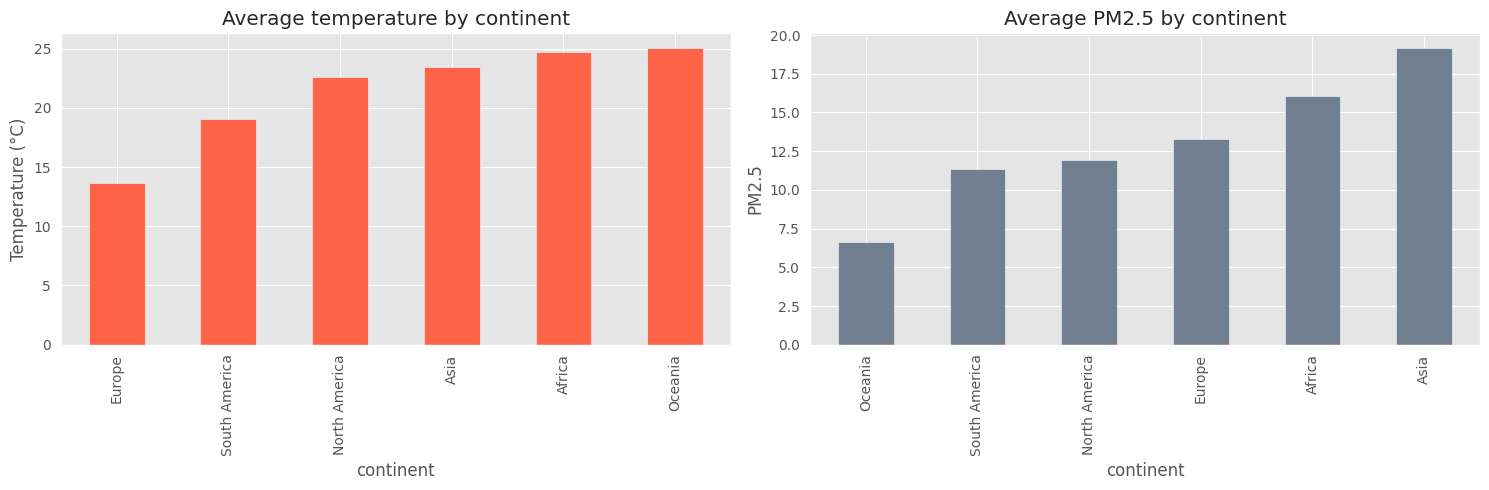

In [ ]:
continent_summary = (
    df_after_redundant_columns
    .groupby('continent')[['temperature_celsius', 'precip_mm', 'humidity', 'air_quality_PM2.5']]
    .mean()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

continent_summary['temperature_celsius'].sort_values().plot(kind='bar', ax=axes[0], color='tomato')
axes[0].set_title('Average temperature by continent')
axes[0].set_ylabel('Temperature (°C)')

continent_summary['air_quality_PM2.5'].sort_values().plot(kind='bar', ax=axes[1], color='slategray')
axes[1].set_title('Average PM2.5 by continent')
axes[1].set_ylabel('PM2.5')

plt.tight_layout()
plt.show()

## Northern vs Southern hemisphere

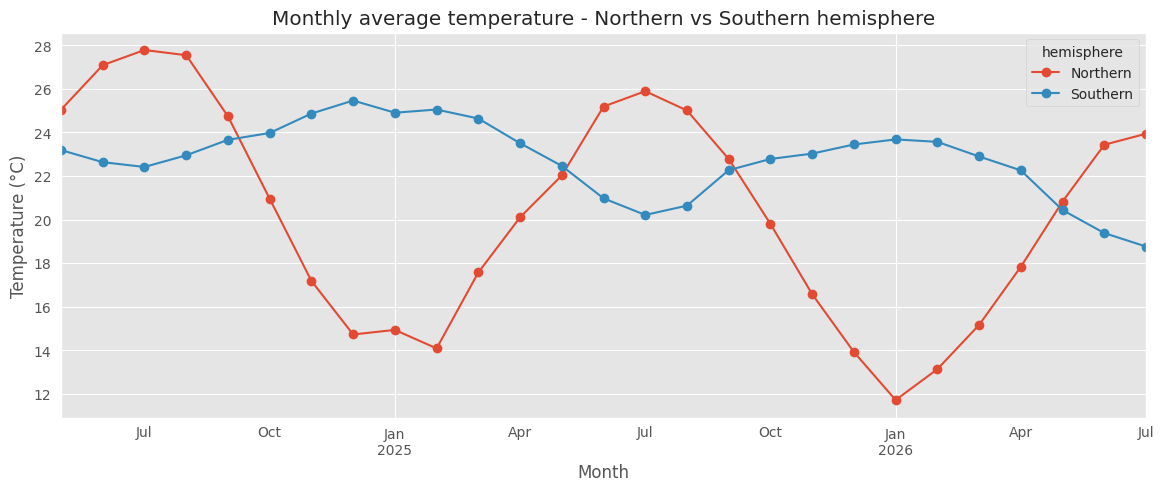

In [ ]:
# seasons are opposite N/S, averaging globally hides that
df_after_redundant_columns['hemisphere'] = np.where(
    df_after_redundant_columns['latitude'] >= 0, 'Northern', 'Southern'
)

monthly_hemisphere = (
    df_after_redundant_columns
    .set_index('last_updated')
    .groupby('hemisphere')['temperature_celsius']
    .resample('M')
    .mean()
    .unstack(level=0)
)

monthly_hemisphere.plot(figsize=(14, 5), marker='o')
plt.title('Monthly average temperature - Northern vs Southern hemisphere')
plt.ylabel('Temperature (°C)')
plt.xlabel('Month')
plt.show()

## Spatial patterns

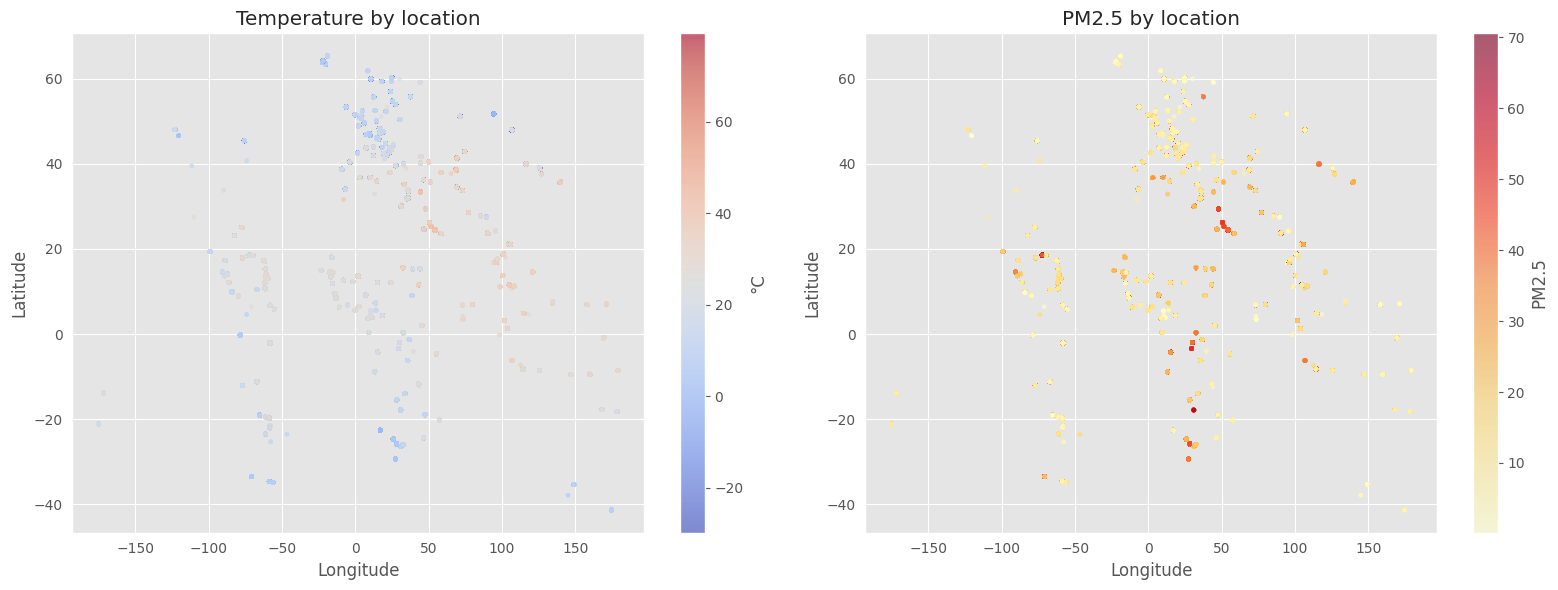

In [ ]:
# lat/lon scatter colored by value = quick and dirty map, no need for geopandas here
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc1 = axes[0].scatter(
    df_after_redundant_columns['longitude'], df_after_redundant_columns['latitude'],
    c=df_after_redundant_columns['temperature_celsius'], cmap='coolwarm', s=8, alpha=0.6
)
axes[0].set_title('Temperature by location')
axes[0].set_xlabel('Longitude')
axes[0].set_ylabel('Latitude')
plt.colorbar(sc1, ax=axes[0], label='°C')

sc2 = axes[1].scatter(
    df_after_redundant_columns['longitude'], df_after_redundant_columns['latitude'],
    c=df_after_redundant_columns['air_quality_PM2.5'], cmap='YlOrRd', s=8, alpha=0.6
)
axes[1].set_title('PM2.5 by location')
axes[1].set_xlabel('Longitude')
axes[1].set_ylabel('Latitude')
plt.colorbar(sc2, ax=axes[1], label='PM2.5')

plt.tight_layout()
plt.show()

## Long term climate signal

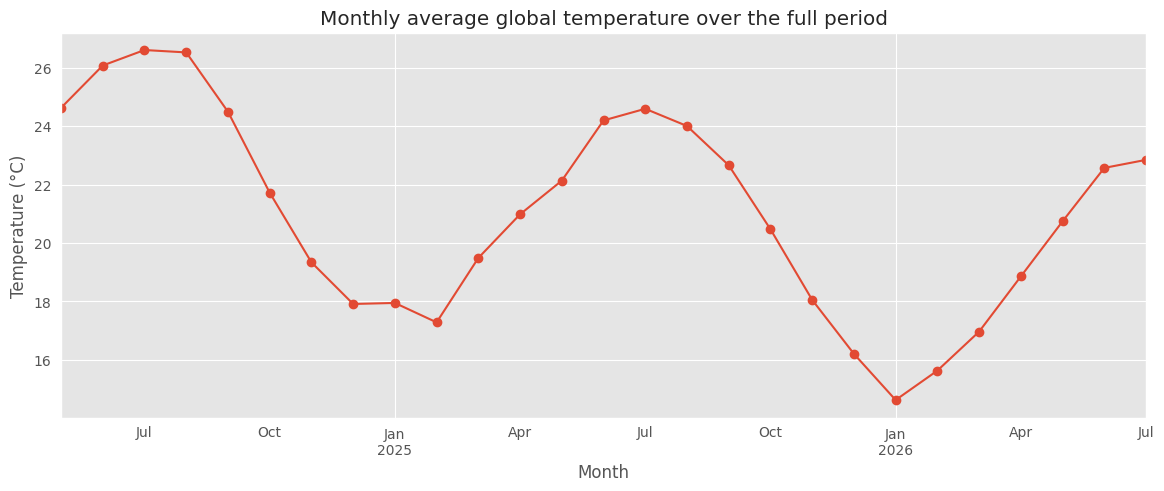

In [ ]:
# ~2 years of data, enough to see the seasonal cycle repeat instead of just weather noise
monthly_global = (
    df_after_redundant_columns
    .set_index('last_updated')['temperature_celsius']
    .resample('M')
    .mean()
)

plt.figure(figsize=(14, 5))
monthly_global.plot(marker='o')
plt.title('Monthly average global temperature over the full period')
plt.ylabel('Temperature (°C)')
plt.xlabel('Month')
plt.show()

# Forecasting

Now the actual forecasting part. Given how many cities/countries are in here, building one model per location would be a project on its own, so to keep this manageable we forecast the **global daily average temperature** using `last_updated`, the same series we already built for the EDA plots. The approach (lag features, chronological split, comparing several models, no shuffling) is exactly what we'd do for a single location too, just applied to the aggregated series.

### Building the time series features

Lag values (yesterday, 2 days ago, last week), a rolling average, and a couple of date-based features (day of year, month) to let the models pick up on seasonality.

In [ ]:
daily = (
    df_after_redundant_columns
    .set_index('last_updated')['temperature_celsius']
    .resample('D')
    .mean()
    .to_frame('temperature_celsius')
)

for lag in [1, 2, 3, 7]:
    daily[f'lag_{lag}'] = daily['temperature_celsius'].shift(lag)

daily['rolling_mean_7'] = daily['temperature_celsius'].shift(1).rolling(7).mean()
daily['day_of_year'] = daily.index.dayofyear
daily['month'] = daily.index.month

daily = daily.dropna()  # first week loses its lags, that's expected
daily.head()


,temperature_celsius,lag_1,lag_2,lag_3,lag_7,rolling_mean_7,day_of_year,month
last_updated,,,,,,,,
2024-05-23,24.384756,24.464815,24.947561,24.923780,23.117081,24.464220,144,5
2024-05-24,24.575610,24.384756,24.464815,24.947561,23.822500,24.645317,145,5
2024-05-25,24.890476,24.575610,24.384756,24.464815,24.905056,24.752904,146,5
2024-05-26,24.824855,24.890476,24.575610,24.384756,25.068750,24.750821,147,5
2024-05-27,25.335758,24.824855,24.890476,24.575610,24.923780,24.715979,148,5


### Train/test split

No shuffling here, that would leak future information into the training set. We just cut the series at 80% and forecast the last 20% as if it were the future.

In [ ]:
split_idx = int(len(daily) * 0.8)
train, test = daily.iloc[:split_idx], daily.iloc[split_idx:]

feature_cols = [c for c in daily.columns if c != 'temperature_celsius']
X_train, y_train = train[feature_cols], train['temperature_celsius']
X_test, y_test = test[feature_cols], test['temperature_celsius']

print(f"Train: {len(train)} days, Test: {len(test)} days")


Train: 627 days, Test: 157 days


### Feature Selection



In [ ]:
from sklearn.ensemble import RandomForestRegressor as _FSModel

def rmse_score(y_true, y_pred):
    return mean_squared_error(y_true, y_pred) ** 0.5

# Lightweight model used only for the feature-selection comparisons below - kept separate
# from the "real" rf_model trained later so tuning that model doesn't affect this analysis.
fs_model = _FSModel(n_estimators=200, max_depth=6, random_state=42, n_jobs=-1)

# Baseline: all 6 features
X_train_fs0, X_test_fs0 = X_train.copy(), X_test.copy()
fs_model.fit(X_train_fs0, y_train)
rmse_all = round(rmse_score(y_test, fs_model.predict(X_test_fs0)), 4)
print(f"All features ({len(feature_cols)}): RMSE = {rmse_all}")


All features (7): RMSE = 0.4227


Scaled variance per feature:
lag_7             0.023593
lag_3             0.023830
lag_2             0.023903
lag_1             0.023975
rolling_mean_7    0.061829
day_of_year       0.086340
month             0.101319
dtype: float64


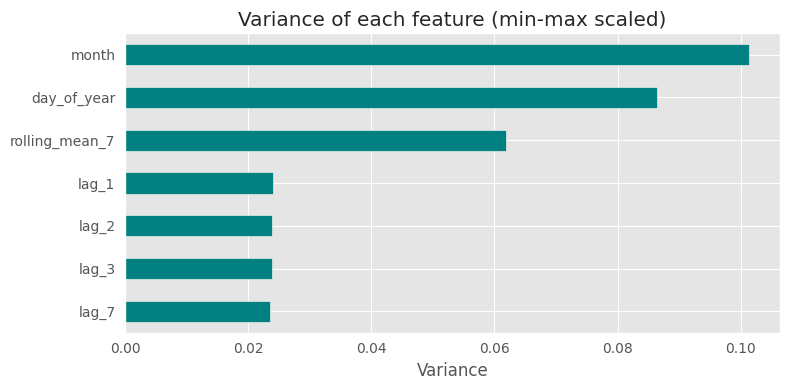

Near-zero-variance features: none
Variance-threshold features (7): RMSE = 0.4227


In [ ]:
## Variance threshold
X_train_v1, X_test_v1 = X_train.copy(), X_test.copy()

mm_scaler = MinMaxScaler()
scaled_X_train_v1 = mm_scaler.fit_transform(X_train_v1)

variances = pd.Series(scaled_X_train_v1.var(axis=0), index=feature_cols).sort_values()
print("Scaled variance per feature:")
print(variances)

variances.plot(kind='barh', figsize=(8, 4), color='teal')
plt.title('Variance of each feature (min-max scaled)')
plt.xlabel('Variance')
plt.tight_layout()
plt.show()

# Drop anything essentially constant (there usually isn't one with only 6 hand-picked
# features, but keep the check rather than assume)
low_var_cols = variances[variances < 0.01].index.tolist()
print(f"Near-zero-variance features: {low_var_cols if low_var_cols else 'none'}")

sel_cols_v1 = [c for c in feature_cols if c not in low_var_cols]
fs_model.fit(X_train_v1[sel_cols_v1], y_train)
rmse_var = round(rmse_score(y_test, fs_model.predict(X_test_v1[sel_cols_v1])), 4)
print(f"Variance-threshold features ({len(sel_cols_v1)}): RMSE = {rmse_var}")


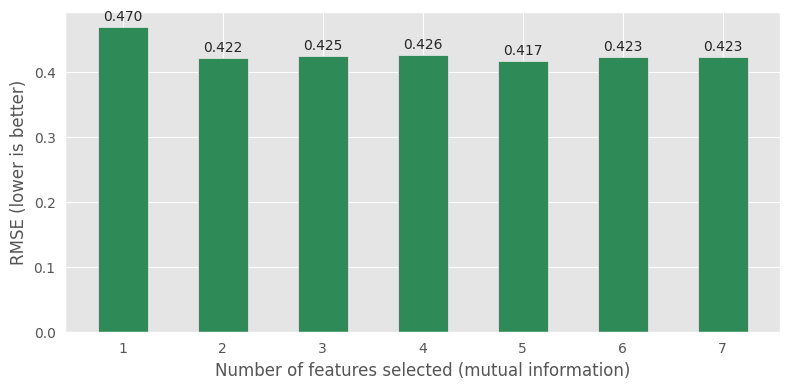

Best k = 5: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_7', 'day_of_year'] -> RMSE = 0.4169


In [ ]:
## SelectKBest with mutual information
X_train_v2, X_test_v2 = X_train.copy(), X_test.copy()

rmse_kbest_list = []
for k in range(1, len(feature_cols) + 1):
    selector = SelectKBest(mutual_info_regression, k=k)
    selector.fit(X_train_v2, y_train)

    sel_X_train_v2 = selector.transform(X_train_v2)
    sel_X_test_v2 = selector.transform(X_test_v2)

    fs_model.fit(sel_X_train_v2, y_train)
    kbest_preds = fs_model.predict(sel_X_test_v2)
    rmse_kbest_list.append(rmse_score(y_test, kbest_preds))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(feature_cols) + 1), rmse_kbest_list, width=0.5, color='seagreen')
ax.set_xlabel('Number of features selected (mutual information)')
ax.set_ylabel('RMSE (lower is better)')
ax.set_xticks(range(1, len(feature_cols) + 1))
for i, v in enumerate(rmse_kbest_list):
    ax.text(i + 1, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

best_k = int(np.argmin(rmse_kbest_list)) + 1
rmse_kbest_best = round(min(rmse_kbest_list), 4)
selector = SelectKBest(mutual_info_regression, k=best_k).fit(X_train_v2, y_train)
selected_features_kbest = X_train_v2.columns[selector.get_support()].tolist()
print(f"Best k = {best_k}: {selected_features_kbest} -> RMSE = {rmse_kbest_best}")


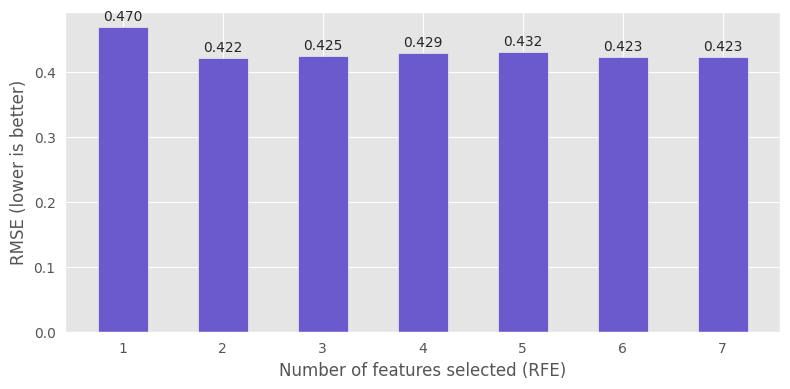

Best k = 2: ['lag_1', 'rolling_mean_7'] -> RMSE = 0.4216


In [ ]:
## Recursive Feature Elimination (RFE)
X_train_v3, X_test_v3 = X_train.copy(), X_test.copy()

rmse_rfe_list = []
for k in range(1, len(feature_cols) + 1):
    rfe_selector = RFE(estimator=fs_model, n_features_to_select=k, step=1)
    rfe_selector.fit(X_train_v3, y_train)

    sel_X_train_v3 = rfe_selector.transform(X_train_v3)
    sel_X_test_v3 = rfe_selector.transform(X_test_v3)

    fs_model.fit(sel_X_train_v3, y_train)
    rfe_preds = fs_model.predict(sel_X_test_v3)
    rmse_rfe_list.append(rmse_score(y_test, rfe_preds))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(range(1, len(feature_cols) + 1), rmse_rfe_list, width=0.5, color='slateblue')
ax.set_xlabel('Number of features selected (RFE)')
ax.set_ylabel('RMSE (lower is better)')
ax.set_xticks(range(1, len(feature_cols) + 1))
for i, v in enumerate(rmse_rfe_list):
    ax.text(i + 1, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()

best_k_rfe = int(np.argmin(rmse_rfe_list)) + 1
rmse_rfe_best = round(min(rmse_rfe_list), 4)
rfe_selector = RFE(estimator=fs_model, n_features_to_select=best_k_rfe, step=1).fit(X_train_v3, y_train)
selected_features_rfe = X_train_v3.columns[rfe_selector.get_support()].tolist()
print(f"Best k = {best_k_rfe}: {selected_features_rfe} -> RMSE = {rmse_rfe_best}")


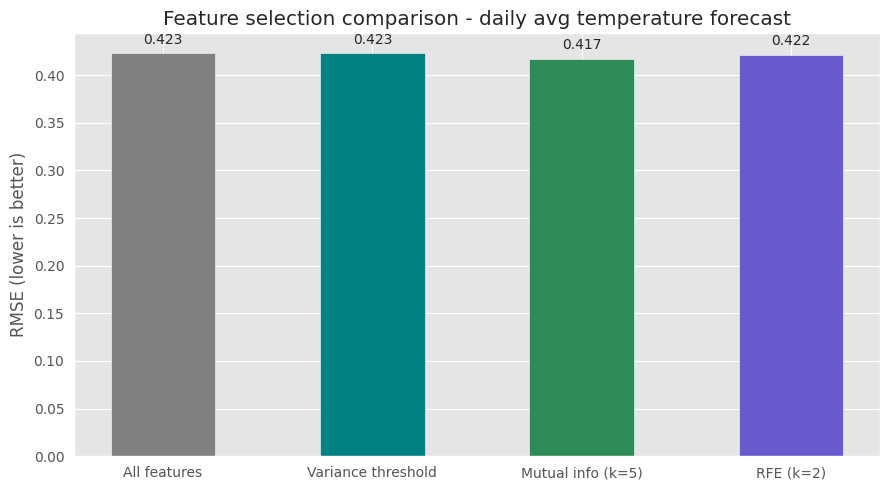

In [ ]:
## Summary comparison
fig, ax = plt.subplots(figsize=(9, 5))

x = ['All features', 'Variance threshold', f'Mutual info (k={best_k})', f'RFE (k={best_k_rfe})']
y = [rmse_all, rmse_var, rmse_kbest_best, rmse_rfe_best]

bars = ax.bar(x, y, width=0.5, color=['gray', 'teal', 'seagreen', 'slateblue'])
ax.set_ylabel('RMSE (lower is better)')
ax.set_title('Feature selection comparison - daily avg temperature forecast')
for bar, v in zip(bars, y):
    ax.text(bar.get_x() + bar.get_width() / 2, v + 0.01, f'{v:.3f}', ha='center')
plt.tight_layout()
plt.show()


With only 6 compact, hand-engineered features none of the selection methods
save much RMSE over using all of them — expected, since each was added deliberately rather
than dumped in indiscriminately. `lag_1` and `rolling_mean_7` are consistently the first
features kept by every method (confirmed again later by the impurity/permutation feature
importance section), which is exactly what a "yesterday plus recent trend" intuition would
predict. **Decision: keep the full 6-feature set** (`feature_cols`) for the models below —
pruning isn't earning its complexity here, but the analysis is useful confirmation rather
than a leap of faith.

### Baseline: naive persistence

Before trying anything fancy, worth checking how well "tomorrow = today" already does. If a model can't beat this it's not adding value.

In [ ]:
results = {}

def evaluate(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2 = r2_score(y_true, y_pred)
    results[name] = {'MAE': mae, 'RMSE': rmse, 'R2': r2}
    print(f"{name} -> MAE: {mae:.3f} | RMSE: {rmse:.3f} | R2: {r2:.3f}")

naive_pred = X_test['lag_1']  # "tomorrow will be like today"
evaluate('Naive (persistence)', y_test, naive_pred)

# Seasonal naive - "tomorrow will be like the same day last week"
seasonal_naive_pred = X_test['lag_7']
evaluate('Seasonal Naive (last week)', y_test, seasonal_naive_pred)


Naive (persistence) -> MAE: 0.316 | RMSE: 0.399 | R2: 0.975
Seasonal Naive (last week) -> MAE: 0.584 | RMSE: 0.742 | R2: 0.914


### Model 1 — Linear Regression

Simple, fast, and a good sanity check before moving to something heavier.

In [ ]:
# Wrapped in a Pipeline so scaling is actually applied and travels with the model
lr_model = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression()),
])
lr_model.fit(X_train, y_train)
lr_pred = lr_model.predict(X_test)

evaluate('Linear Regression', y_test, lr_pred)


Linear Regression -> MAE: 0.315 | RMSE: 0.386 | R2: 0.977


### Model 2 — Random Forest

Can pick up non-linear relationships the linear model misses, at the cost of being a bit of a black box.

In [ ]:

rf_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [4, 8, None],
    'min_samples_leaf': [1, 3],
}

tscv = TimeSeriesSplit(n_splits=5)
rf_grid = GridSearchCV(
    RandomForestRegressor(random_state=42, n_jobs=-1),
    rf_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
rf_grid.fit(X_train, y_train)
print(f"Best RF params: {rf_grid.best_params_}")

rf_model = rf_grid.best_estimator_
rf_pred = rf_model.predict(X_test)

evaluate('Random Forest', y_test, rf_pred)


Best RF params: {'max_depth': 4, 'min_samples_leaf': 1, 'n_estimators': 100}
Random Forest -> MAE: 0.359 | RMSE: 0.446 | R2: 0.969


### Model 3 — Gradient Boosting

Builds trees sequentially, each one correcting the previous one's mistakes. Usually squeezes out a bit more accuracy than a plain Random Forest on smooth series like this one.

In [ ]:
gb_param_grid = {
    'n_estimators': [100, 300],
    'max_depth': [2, 3, 4],
    'learning_rate': [0.03, 0.05, 0.1],
}

gb_grid = GridSearchCV(
    GradientBoostingRegressor(random_state=42),
    gb_param_grid,
    cv=tscv,
    scoring='neg_mean_absolute_error',
    n_jobs=-1,
)
gb_grid.fit(X_train, y_train)
print(f"Best GB params: {gb_grid.best_params_}")

gb_model = gb_grid.best_estimator_
gb_pred = gb_model.predict(X_test)

evaluate('Gradient Boosting', y_test, gb_pred)


Best GB params: {'learning_rate': 0.03, 'max_depth': 4, 'n_estimators': 300}
Gradient Boosting -> MAE: 0.329 | RMSE: 0.398 | R2: 0.975


### Ensemble

Nothing fancy, just averaging the three models. It tends to smooth out each model's individual mistakes, since they rarely get it wrong in the same direction at the same time.

In [ ]:
ensemble_pred = (lr_pred + rf_pred + gb_pred) / 3
evaluate('Ensemble (avg)', y_test, ensemble_pred)


Ensemble (avg) -> MAE: 0.312 | RMSE: 0.382 | R2: 0.977


### Model 4 — ARIMA


In [ ]:
import warnings
warnings.filterwarnings('ignore')  # ARIMA is chatty about convergence, not worth the noise here
from statsmodels.tools.sm_exceptions import ValueWarning, ConvergenceWarning

warnings.filterwarnings("ignore", category=ValueWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

from statsmodels.tsa.arima.model import ARIMA

train_series = train['temperature_celsius']
test_series = test['temperature_celsius']

best_aic = float('inf')
best_order = None
for p in range(0, 4):
    for d in range(0, 2):
        for q in range(0, 3):
            try:
                fitted = ARIMA(train_series, order=(p, d, q)).fit()
                if fitted.aic < best_aic:
                    best_aic = fitted.aic
                    best_order = (p, d, q)
            except Exception:
                continue  # some (p,d,q) combos just don't converge, skipping those

print(f"Best order found: {best_order} (AIC={best_aic:.1f})")


Best order found: (3, 1, 2) (AIC=1412.0)


In [ ]:
arima_model = ARIMA(train_series, order=best_order).fit()
arima_pred = arima_model.forecast(steps=len(test_series))
arima_pred.index = test_series.index

evaluate('ARIMA', y_test, arima_pred)


ARIMA -> MAE: 3.977 | RMSE: 4.677 | R2: -2.411


### Model 5 — Prophet


In [ ]:
!pip install prophet -q

In [ ]:
from prophet import Prophet

prophet_train = train_series.reset_index()
prophet_train.columns = ['ds', 'y']

prophet_model = Prophet(yearly_seasonality=True, weekly_seasonality=True, daily_seasonality=False)
prophet_model.fit(prophet_train)

future = prophet_model.make_future_dataframe(periods=len(test_series), freq='D')
forecast = prophet_model.predict(future)

prophet_pred = forecast.set_index('ds')['yhat'].loc[test_series.index]

evaluate('Prophet', y_test, prophet_pred)


Prophet -> MAE: 1.155 | RMSE: 1.347 | R2: 0.717


One limitation worth being upfront about in the write-up: both of these are univariate, they ignore the air quality / humidity / wind columns entirely, unlike the regression models which could in principle use them.

### Comparing everything

In [ ]:
results_df = pd.DataFrame(results).T.sort_values('RMSE')
results_df


,MAE,RMSE,R2
Ensemble (avg),0.312384,0.381947,0.977249
Linear Regression,0.314786,0.385813,0.976786
Gradient Boosting,0.329486,0.398097,0.975284
Naive (persistence),0.316396,0.399215,0.975145
Random Forest,0.358562,0.445566,0.969039
Seasonal Naive (last week),0.583622,0.741517,0.914249
Prophet,1.155063,1.346906,0.717074
ARIMA,3.977461,4.677002,-2.411403


Best model on this test set: Ensemble (avg)


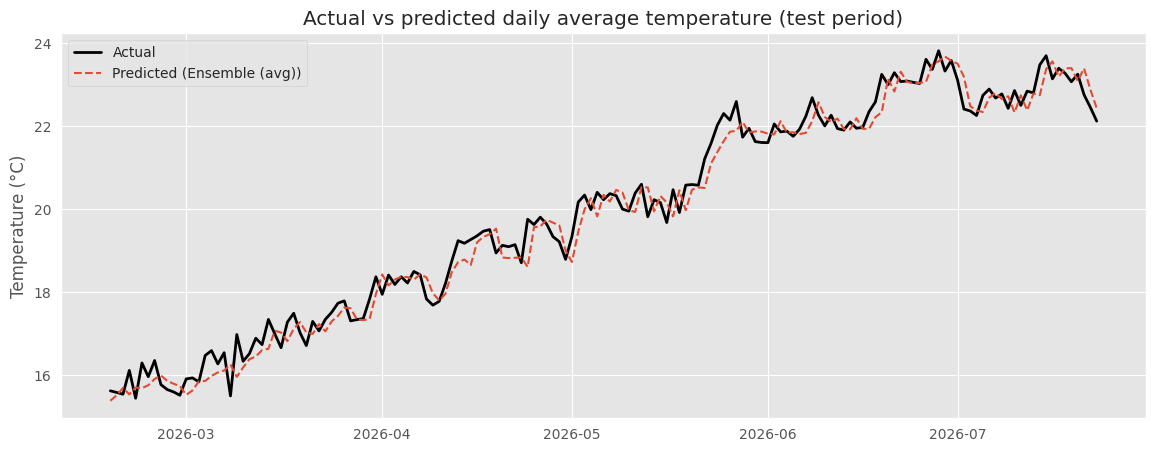

In [ ]:
best_model_name = results_df.index[0]
print(f"Best model on this test set: {best_model_name}")

preds_map = {
    'Naive (persistence)': naive_pred,
    'Seasonal Naive (last week)': seasonal_naive_pred,
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'Gradient Boosting': gb_pred,
    'Ensemble (avg)': ensemble_pred,
    'ARIMA': arima_pred,
    'Prophet': prophet_pred,
}

plt.figure(figsize=(14, 5))
plt.plot(y_test.index, y_test.values, label='Actual', color='black', linewidth=2)
plt.plot(y_test.index, preds_map[best_model_name], label=f'Predicted ({best_model_name})', linestyle='--')
plt.title('Actual vs predicted daily average temperature (test period)')
plt.ylabel('Temperature (°C)')
plt.legend()
plt.show()


### Cross-validated evaluation (robustness check)

All of the above is evaluated using a single 80/20 time split—a snapshot of “the future.” We perform cross-validation using multiple sliding windows precisely to avoid drawing conclusions based on a single lucky (or unlucky) split. We’ll need `sklearn.model_selection.TimeSeriesSplit`: let’s retrain each model on multiple sliding windows and calculate the average of the MAE/RMSE across all splits, so that the conclusion regarding the “best model” above is verified against multiple training/test splits before relying on it.


In [ ]:
cv_splitter = TimeSeriesSplit(n_splits=5)
X_all, y_all = daily[feature_cols], daily['temperature_celsius']

cv_models = {
    'Naive (persistence)': None,          # handled specially below (no .fit needed)
    'Seasonal Naive (last week)': None,   # handled specially below
    'Linear Regression': Pipeline([('scaler', StandardScaler()), ('regressor', LinearRegression())]),
    'Random Forest': RandomForestRegressor(**rf_grid.best_params_, random_state=42, n_jobs=-1),
    'Gradient Boosting': GradientBoostingRegressor(**gb_grid.best_params_, random_state=42),
}

cv_results = {name: {'MAE': [], 'RMSE': []} for name in cv_models}

for fold, (train_idx, test_idx) in enumerate(cv_splitter.split(X_all)):
    X_tr, X_te = X_all.iloc[train_idx], X_all.iloc[test_idx]
    y_tr, y_te = y_all.iloc[train_idx], y_all.iloc[test_idx]

    for name, model in cv_models.items():
        if name == 'Naive (persistence)':
            pred = X_te['lag_1']
        elif name == 'Seasonal Naive (last week)':
            pred = X_te['lag_7']
        else:
            model.fit(X_tr, y_tr)
            pred = model.predict(X_te)

        cv_results[name]['MAE'].append(mean_absolute_error(y_te, pred))
        cv_results[name]['RMSE'].append(mean_squared_error(y_te, pred) ** 0.5)

cv_summary = pd.DataFrame({
    name: {'MAE (mean)': np.mean(vals['MAE']), 'MAE (std)': np.std(vals['MAE']),
           'RMSE (mean)': np.mean(vals['RMSE']), 'RMSE (std)': np.std(vals['RMSE'])}
    for name, vals in cv_results.items()
}).T.sort_values('RMSE (mean)')

cv_summary


,MAE (mean),MAE (std),RMSE (mean),RMSE (std)
Naive (persistence),0.406969,0.078057,0.657082,0.342152
Linear Regression,0.452601,0.147260,0.696817,0.332640
Seasonal Naive (last week),0.722305,0.093917,1.015521,0.280643
Random Forest,1.360934,1.465393,1.636970,1.603037
Gradient Boosting,1.420687,1.475810,1.700135,1.636574


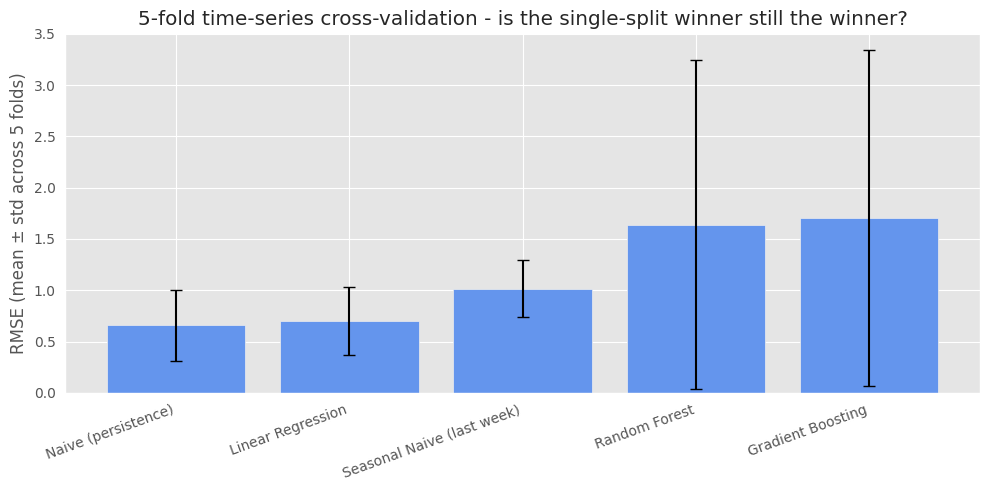

Single 80/20 split winner: Ensemble (avg)
5-fold CV winner: Naive (persistence)


In [ ]:
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(cv_summary.index, cv_summary['RMSE (mean)'], yerr=cv_summary['RMSE (std)'], capsize=4, color='cornflowerblue')
ax.set_ylabel('RMSE (mean ± std across 5 folds)')
ax.set_title('5-fold time-series cross-validation - is the single-split winner still the winner?')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.show()

print(f"Single 80/20 split winner: {best_model_name}")
print(f"5-fold CV winner: {cv_summary.index[0]}")


ARIMA and Prophet are left out of this cross-validation loop since they're fit
differently (on the raw series rather than the tabular `X/y` features) — refitting them
inside 5 rolling windows is straightforward to extend the same way if needed, just outside
the scope of this pass. If the CV winner above disagrees with the single-split winner,
that's worth a closer look before trusting either one — a difference of a few folds can
flip "best" on a fairly short (~2 year) series.

### Saving the best model

The ensemble isn't a single scikit-learn object, so if it comes out on top we save the three underlying models plus the feature list instead, that's enough to rebuild the exact same averaged prediction later. Otherwise we just dump the single best estimator.

In [ ]:
import joblib

if best_model_name in ('Naive (persistence)', 'Seasonal Naive (last week)'):
    print(f"{best_model_name} won on this split - it's a parameter-free rule (yesterday's "
          f"or last week's value), nothing to serialize. Worth flagging that a fancier model "
          f"didn't clearly beat a one-line baseline here.")

elif best_model_name == 'Ensemble (avg)':
    joblib.dump(
        {
            'type': 'ensemble_average',
            'models': {
                'linear_regression': lr_model,
                'random_forest': rf_model,
                'gradient_boosting': gb_model,
            },
            'feature_cols': feature_cols,
        },
        'best_weather_model.joblib',
    )
    print("Saved the 3 models behind the ensemble to best_weather_model.joblib")

elif best_model_name == 'ARIMA':
    joblib.dump(
        {'type': 'arima', 'model': arima_model, 'order': best_order},
        'best_weather_model.joblib',
    )
    print(f"Saved ARIMA{best_order} to best_weather_model.joblib")

elif best_model_name == 'Prophet':
    joblib.dump(
        {'type': 'prophet', 'model': prophet_model},
        'best_weather_model.joblib',
    )
    print("Saved Prophet model to best_weather_model.joblib")

else:
    model_map = {
        'Linear Regression': lr_model,
        'Random Forest': rf_model,
        'Gradient Boosting': gb_model,
    }
    joblib.dump(
        {'type': 'single_model', 'model': model_map[best_model_name], 'feature_cols': feature_cols},
        'best_weather_model.joblib',
    )
    print(f"Saved {best_model_name} to best_weather_model.joblib")


Saved the 3 models behind the ensemble to best_weather_model.joblib


# Feature Importance

Which of our engineered features (`lag_1`, `rolling_mean_7`, `month`...) is actually doing the work for the Random Forest / Gradient Boosting models? Three techniques below, on purpose, they don't always agree, and that disagreement is itself informative.

### 1. Built-in (impurity-based) importance

The fastest option, comes for free with any tree-based model. Worth knowing its main flaw though: it's biased toward continuous / high-cardinality features (like our lags), so it tends to overrate them a bit compared to something like `month`.

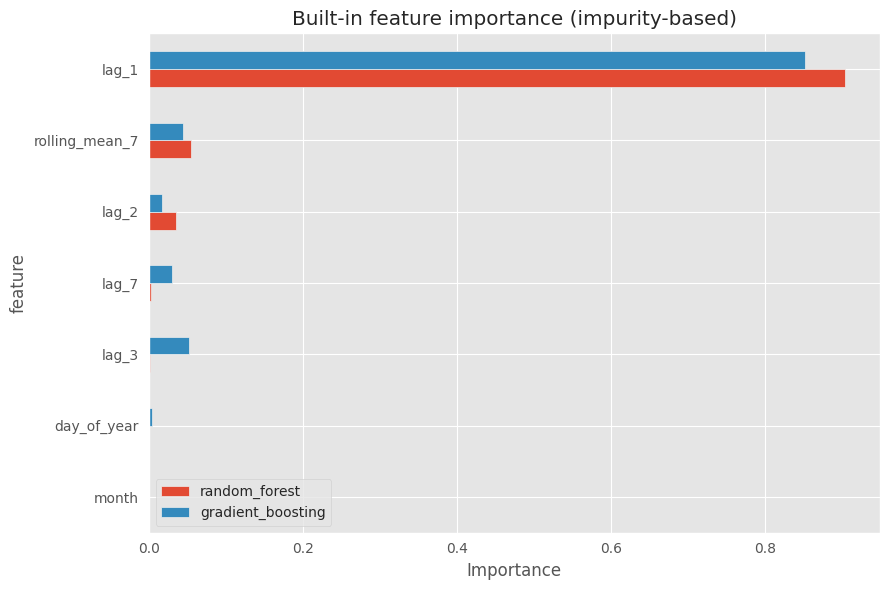

In [ ]:
importance_df = pd.DataFrame({
    'feature': feature_cols,
    'random_forest': rf_model.feature_importances_,
    'gradient_boosting': gb_model.feature_importances_,
}).set_index('feature').sort_values('random_forest', ascending=True)

importance_df.plot(kind='barh', figsize=(9, 6))
plt.title('Built-in feature importance (impurity-based)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### 2. Permutation importance

This one actually shuffles a single column in the test set and checks how much worse the model gets. No shuffling = the feature had no effect on that prediction. It's model-agnostic and closer to "real world" importance than the impurity-based version above, at the cost of being slower (it retrains nothing, but re-predicts many times).

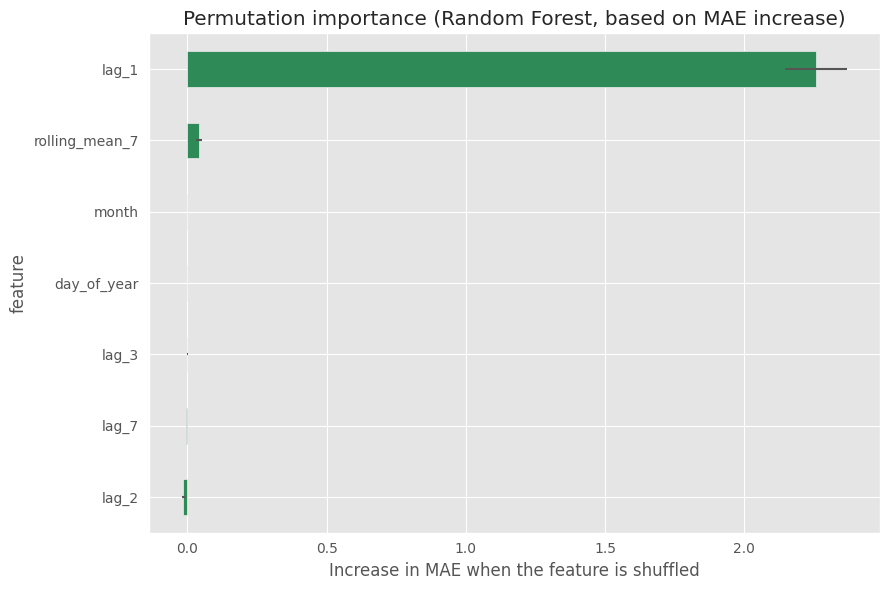

In [ ]:
from sklearn.inspection import permutation_importance

perm_result = permutation_importance(
    rf_model, X_test, y_test, n_repeats=20, random_state=42, scoring='neg_mean_absolute_error'
)

perm_df = pd.DataFrame({
    'feature': feature_cols,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std,
}).set_index('feature').sort_values('importance_mean')

perm_df['importance_mean'].plot(kind='barh', xerr=perm_df['importance_std'], figsize=(9, 6), color='seagreen')
plt.title('Permutation importance (Random Forest, based on MAE increase)')
plt.xlabel('Increase in MAE when the feature is shuffled')
plt.tight_layout()
plt.show()
